# Librerias

In [1]:
import os
import sqlite3
import warnings
import pandas as pd
import numpy  as np
import plotly.express         as px
import plotly.graph_objects   as go
from   plotly.subplots import make_subplots
from scipy  import stats
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from joblib import Parallel, delayed
from dotenv import load_dotenv
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, roc_auc_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve
import joblib
import tensorflow as tf
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, RocCurveDisplay
import matplotlib.gridspec as gridspec

# Configuracion para el dataframe

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [3]:
warnings.filterwarnings('ignore')

# Rutas

In [4]:
ROOT = Path.cwd().parent

load_dotenv(ROOT / '.env')
DB_PATH = str(ROOT / 'db' / 'gaming_warehouse.db')
IMAGENES_PATH = str(ROOT / 'Imagenes') + '/'

# funciones

In [5]:
def query(sql):
    with sqlite3.connect(DB_PATH) as conn:
        return pd.read_sql_query(sql, conn)

# llenar mis dataframes

In [6]:
df_juegos = query("""
    SELECT j.*
    FROM   CAT_Juego j
    WHERE  j.juego_id NOT IN (SELECT juego_id_dlc FROM REL_Juego_DLC)
      AND  j.id_steam IS NOT NULL
""")

steam_ids  = set(df_juegos['juego_id'])
itad_ids   = set(df_juegos['itad_id_texto'].dropna())

df_hist     = query("SELECT * FROM Hist_Precios_ITAD")
df_hist     = df_hist[df_hist['itad_id_texto'].isin(itad_ids)].reset_index(drop=True)
df_hist['fecha'] = pd.to_datetime(df_hist['fecha_unix'], unit='s')

df_actuales = query("SELECT * FROM Datos_Actuales_ITAD")
df_actuales = df_actuales[df_actuales['itad_id_texto'].isin(itad_ids)].reset_index(drop=True)

df_reviews  = query("SELECT * FROM Hist_Steam_Reviews")
df_reviews  = df_reviews[df_reviews['juego_id'].isin(steam_ids)].reset_index(drop=True)

df_generos   = query("""
    SELECT r.juego_id, GROUP_CONCAT(g.nombre, '|') AS generos
    FROM   REL_Juego_Genero r
    JOIN   CAT_Genero g ON r.genero_id = g.genero_id
    WHERE  r.juego_id IN (SELECT juego_id FROM CAT_Juego
                          WHERE  id_steam IS NOT NULL
                            AND  juego_id NOT IN (SELECT juego_id_dlc FROM REL_Juego_DLC))
    GROUP  BY r.juego_id
""")

df_etiquetas = query("""
    SELECT r.juego_id, GROUP_CONCAT(e.nombre, '|') AS etiquetas
    FROM   REL_Juego_Etiqueta r
    JOIN   CAT_Etiqueta e ON r.etiqueta_id = e.etiqueta_id
    WHERE  r.juego_id IN (SELECT juego_id FROM CAT_Juego
                          WHERE  id_steam IS NOT NULL
                            AND  juego_id NOT IN (SELECT juego_id_dlc FROM REL_Juego_DLC))
    GROUP  BY r.juego_id
""")

df_modos     = query("""
    SELECT r.juego_id, GROUP_CONCAT(m.nombre, '|') AS modos
    FROM   REL_Juego_Modo r
    JOIN   CAT_Modo_Juego m ON r.modo_id = m.modo_id
    WHERE  r.juego_id IN (SELECT juego_id FROM CAT_Juego
                          WHERE  id_steam IS NOT NULL
                            AND  juego_id NOT IN (SELECT juego_id_dlc FROM REL_Juego_DLC))
    GROUP  BY r.juego_id
""")

df_dlcs = query("SELECT * FROM REL_Juego_DLC")


In [7]:
print(f"CAT_Juego con id_steam: {len(df_juegos):,}")
print(f"Hist_Precios_ITAD : {len(df_hist):,}")
print(f"Datos_Actuales_ITAD : {len(df_actuales):,}")
print(f"Hist_Steam_Reviews : {len(df_reviews):,}")
print(f"itad_ids con historial : {df_hist['itad_id_texto'].nunique():,}")
print(f"juego_ids con reseñas : {df_reviews['juego_id'].nunique():,}")
print(f"juevos dlc :{len(df_dlcs):,}")

CAT_Juego con id_steam: 6,399
Hist_Precios_ITAD : 516,255
Datos_Actuales_ITAD : 6,389
Hist_Steam_Reviews : 550,692
itad_ids con historial : 6,250
juego_ids con reseñas : 5,468
juevos dlc :1,367


In [8]:
tablas = {
    'CAT_Juego' : df_juegos,
    'Hist_Precios_ITAD' : df_hist,
    'Datos_Actuales_ITAD' : df_actuales,
    'Hist_Steam_Reviews' : df_reviews,
    'Gneros' : df_generos,
    'Etiquetas' : df_etiquetas,
    'Modos' : df_modos,
    'dlc' : df_dlcs,
}

for nombre, df in tablas.items():
    print(f"{nombre}  {df.shape}")

CAT_Juego  (6399, 28)
Hist_Precios_ITAD  (516255, 6)
Datos_Actuales_ITAD  (6389, 8)
Hist_Steam_Reviews  (550692, 16)
Gneros  (6396, 2)
Etiquetas  (5661, 2)
Modos  (6398, 2)
dlc  (1367, 2)


In [9]:
print("Columnas Hist_Precios_ITAD :", df_hist.columns.tolist())
print("Columnas Datos_Actuales_ITAD:", df_actuales.columns.tolist())
print("Columnas CAT_Juego:", df_juegos.columns.tolist())
print("Columnas Hist_Steam_Reviews :", df_reviews.columns.tolist())

Columnas Hist_Precios_ITAD : ['itad_id_texto', 'precio_base', 'precio', 'descuento', 'fecha_unix', 'fecha']
Columnas Datos_Actuales_ITAD: ['itad_id_texto', 'precio_actual', 'precio_minimo', 'fecha_minimo', 'en_bundle', 'fecha_actualizacion', 'descuento_actual', 'expiry']
Columnas CAT_Juego: ['juego_id', 'id_igdb', 'id_steam', 'titulo', 'categoria', 'fecha_lanzamiento', 'resumen', 'historia', 'url_portada', 'puntuacion_igdb', 'conteo_votos_igdb', 'conteo_dlc', 'conteo_videos', 'hltb_historia_principal', 'hltb_historia_extra', 'hltb_completacionista', 'steam_price_initial', 'steam_price_final', 'steam_discount_percent', 'metacritic_score', 'recommendations_count', 'achievements_count', 'steam_languages', 'pc_requirements_json', 'itad_id_texto', 'hltb_idINTEGER', 'hltb_procesado', 'hltb_id']
Columnas Hist_Steam_Reviews : ['resena_id', 'juego_id', 'resena_texto', 'recomendado', 'votos_utiles', 'votos_graciosos', 'puntuacion_ponderada', 'minutos_al_resenar', 'minutos_totales', 'fecha_creaci

# Estatus del catalogo

## que tengo vacio

In [10]:
nulos = df_juegos.isnull().sum()
pct   = (nulos / len(df_juegos) * 100).round(1)

resumen_nulos = (pd.DataFrame({'nulos': nulos, 'pct': pct})
                   .query('nulos > 0')
                   .sort_values('pct', ascending=False))

print(f"Total juegos: {len(df_juegos):,}")
print(f"Columnas con nulos: {len(resumen_nulos)} / {df_juegos.shape[1]}\n")
print(resumen_nulos.to_string())

# se me fue hltb_idINTEGER
# lade tiempo de comletar tomaran un tiempo en llenarse
# metatric score solo un tercio llena
#  steam_languages,achievements_count,steam_discount_percent son casi 1 tercio nuos pero puede deberse aque no todos lo juegos estan en staeam ya que concide mas o menos con id_steam 

Total juegos: 6,399
Columnas con nulos: 14 / 28

                         nulos    pct
hltb_idINTEGER            6399 100.00
metacritic_score          3703  57.90
hltb_completacionista     1716  26.80
hltb_historia_extra       1702  26.60
hltb_historia_principal   1543  24.10
hltb_id                   1393  21.80
steam_languages             82   1.30
achievements_count          69   1.10
steam_price_initial         69   1.10
steam_discount_percent      69   1.10
pc_requirements_json        69   1.10
recommendations_count       69   1.10
itad_id_texto                8   0.10
fecha_lanzamiento            3   0.00


# que tenfo lleno en campos que me interesan

In [11]:
campos = {
    'IGDB score' : 'puntuacion_igdb',
    'Metacritic' : 'metacritic_score',
    'HLTB historia': 'hltb_historia_principal',
    'HLTB extra': 'hltb_historia_extra',
    'HLTB completacio.' : 'hltb_completacionista',
    'Steam precio': 'steam_price_initial',
    'Steam descuento': 'steam_discount_percent',
    'Recomendaciones' : 'recommendations_count',
    'Achievements' : 'achievements_count',
    'itad_id_texto' : 'itad_id_texto',
}

for nombre, col in campos.items():
    n_ok = df_juegos[col].notna().sum()
    pct= 100 * n_ok / len(df_juegos)
    print(f"{nombre} {pct:5.1f}%  ({n_ok:,})")


IGDB score 100.0%  (6,399)
Metacritic  42.1%  (2,696)
HLTB historia  75.9%  (4,856)
HLTB extra  73.4%  (4,697)
HLTB completacio.  73.2%  (4,683)
Steam precio  98.9%  (6,330)
Steam descuento  98.9%  (6,330)
Recomendaciones  98.9%  (6,330)
Achievements  98.9%  (6,330)
itad_id_texto  99.9%  (6,391)


## Distribución de categoría

In [12]:
print(df_juegos['categoria'].value_counts(dropna=False).to_string())

print(f"Total DLCs en REL_Juego_DLC : {len(df_dlcs):,}")
print(f"Juegos base con al menos 1 DLC: {df_dlcs['juego_id_principal'].nunique():,}")
print(f"DLCs promedio por juego: {len(df_dlcs)/df_dlcs['juego_id_principal'].nunique():.1f}")

sin_itad = df_juegos['itad_id_texto'].isna().sum()
print(f"Juegos sin itad_id_texto: {sin_itad:,}  ({100*sin_itad/len(df_juegos):.1f}%)")

df_juegos['fecha_lanzamiento'] = pd.to_datetime(df_juegos['fecha_lanzamiento'], errors='coerce')
print(f"Rango fechas lanzamiento: {df_juegos['fecha_lanzamiento'].min().year} – {df_juegos['fecha_lanzamiento'].max().year}")
print(f"Sin fecha de lanzamiento: {df_juegos['fecha_lanzamiento'].isna().sum():,}")


categoria
Juego principal            6041
Bundle                      129
Juego ampliado               66
Remasterización              65
Remake                       59
Port                         36
Expansión independiente       3
Total DLCs en REL_Juego_DLC : 1,367
Juegos base con al menos 1 DLC: 761
DLCs promedio por juego: 1.8
Juegos sin itad_id_texto: 8  (0.1%)
Rango fechas lanzamiento: 1980 – 2026
Sin fecha de lanzamiento: 3


## Graficar mis datos

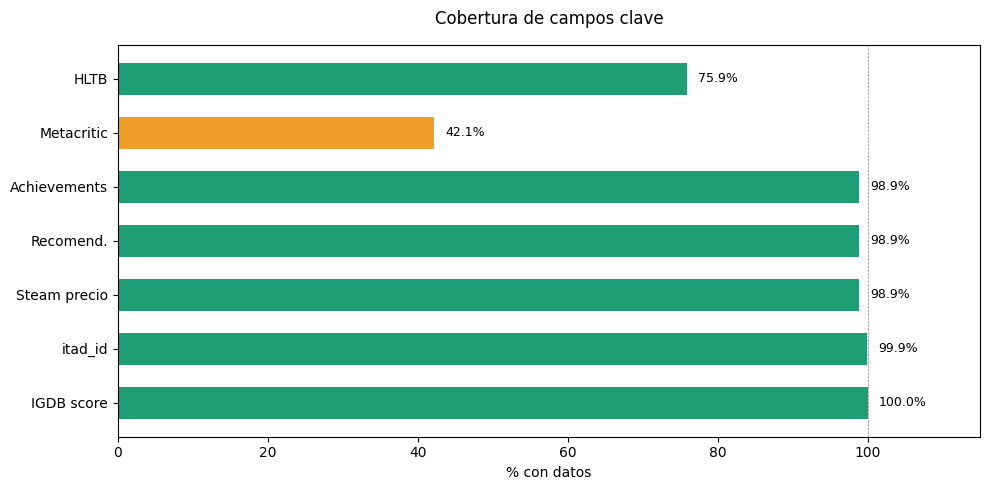

In [13]:
plt.figure(figsize=(10, 5))
campos_viz = {
    'IGDB score' : 'puntuacion_igdb',
    'itad_id' : 'itad_id_texto',
    'Steam precio' : 'steam_price_initial',
    'Recomend.' : 'recommendations_count',
    'Achievements' : 'achievements_count',
    'Metacritic' : 'metacritic_score',
    'HLTB' : 'hltb_historia_principal',
}

nombres = list(campos_viz.keys())
pcts    = [100 * df_juegos[c].notna().sum() / len(df_juegos) for c in campos_viz.values()]
colores = ['#1D9E75' if p >= 70 else ('#EF9F27' if p >= 30 else '#E24B4A') for p in pcts]

titulo="Cobertura de campos clave"

bars = plt.barh(nombres, pcts, color=colores, height=0.6)
plt.xlim(0, 115)
plt.xlabel('% con datos')
plt.title(titulo, fontsize=12, pad=15)
plt.axvline(100, color='gray', lw=0.5, ls='--')

for bar, pct in zip(bars, pcts):
    plt.text(pct + 1.5, bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(IMAGENES_PATH +titulo+ '.png', dpi=150, bbox_inches='tight')
plt.show()

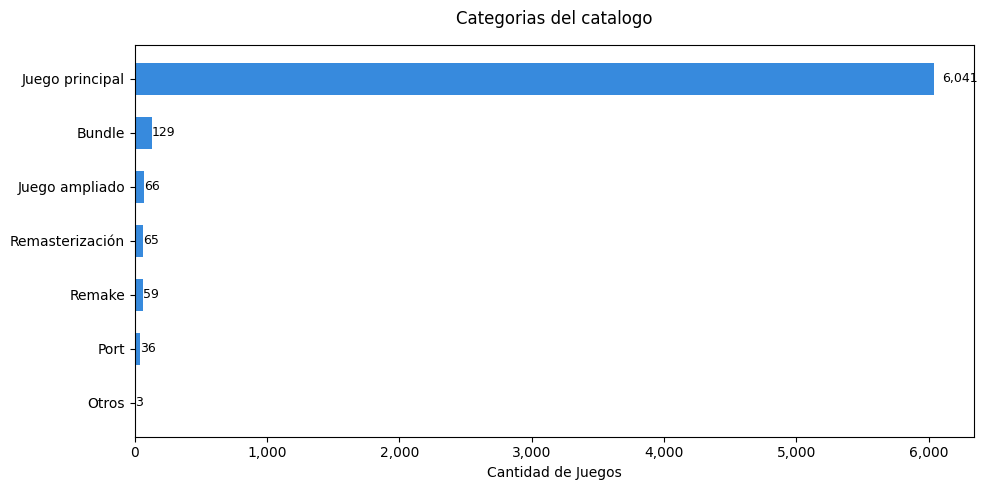

In [14]:
plt.figure(figsize=(10, 5))
cats = df_juegos['categoria'].value_counts()
cats_top = cats.head(6)
otros    = cats.iloc[6:].sum()
cats_plot = pd.concat([cats_top, pd.Series({'Otros': otros})])

titulo="Categorias del catalogo"
plt.barh(cats_plot.index[::-1], cats_plot.values[::-1], color='#378ADD', height=0.6)
plt.xlabel('Cantidad de Juegos')
plt.title(titulo, fontsize=12, pad=15)

# Formateador de miles
import matplotlib.ticker as mticker
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for i, v in enumerate(cats_plot.values[::-1]):
    plt.text(v + (v * 0.01), i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo +".png", dpi=150, bbox_inches='tight')
plt.show()

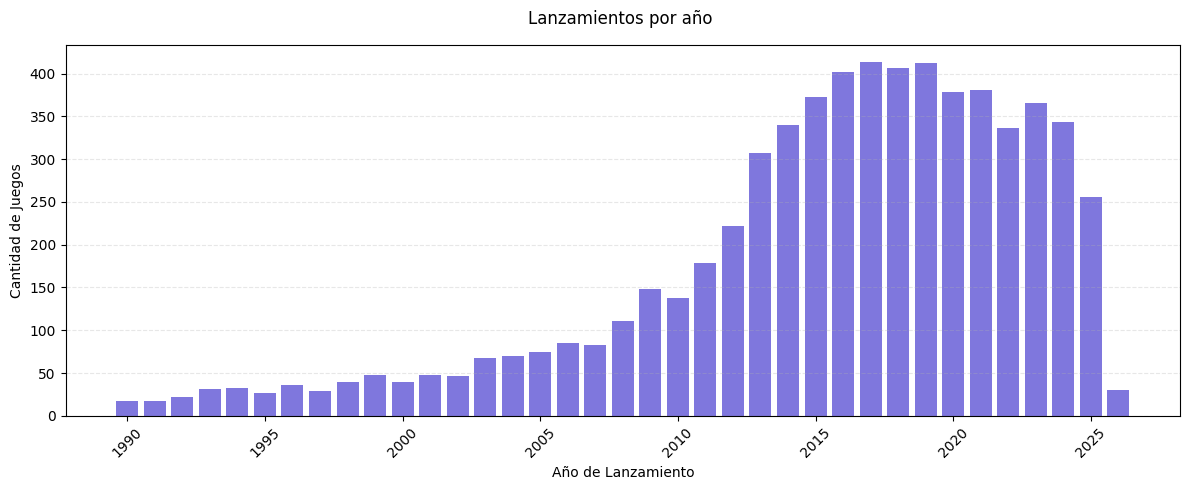

In [15]:
plt.figure(figsize=(12, 5))
por_anio = (df_juegos['fecha_lanzamiento'].dt.year
            .value_counts().sort_index())
por_anio = por_anio[(por_anio.index >= 1990) & (por_anio.index <= 2026)]

titulo="Lanzamientos por año "

plt.bar(por_anio.index, por_anio.values, color='#7F77DD', width=0.8)
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Cantidad de Juegos')
plt.title(titulo, fontsize=12, pad=15)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

## Clasicos describe

In [16]:
df_hist

,itad_id_texto,precio_base,precio,descuento,fecha_unix,fecha
0,018d937f-03e2-7281-a961-037a2d279a92,59.99,59.99,0,1741090525,2025-03-04 12:15:25
1,018d937f-03e2-7281-a961-037a2d279a92,29.99,29.99,0,1609872559,2021-01-05 18:49:19
2,018d937f-03e2-7281-a961-037a2d279a92,29.99,14.99,50,1608662061,2020-12-22 18:34:21
3,018d937f-03e2-7281-a961-037a2d279a92,29.99,29.99,0,1606847026,2020-12-01 18:23:46
4,018d937f-03e2-7281-a961-037a2d279a92,29.99,14.99,50,1606328860,2020-11-25 18:27:40
...,...,...,...,...,...,...
516250,018d937f-0998-7216-a664-200759cfec96,9.99,9.99,0,1471293922,2016-08-15 20:45:22
516251,018d937f-0998-7216-a664-200759cfec96,9.99,1.99,80,1470685527,2016-08-08 19:45:27
516252,018d937f-0998-7216-a664-200759cfec96,9.99,9.99,0,1467649526,2016-07-04 16:25:26
516253,018d937f-0998-7216-a664-200759cfec96,9.99,1.99,80,1466708003,2016-06-23 18:53:23


In [17]:
print(f"Registros totales: {len(df_hist):,}")
print(f"Juegos únicos (itad_id): {df_hist['itad_id_texto'].nunique():,}")
print(f"fecha minima: {df_hist['fecha'].min().date()}")
print(f"fecha maxima: {df_hist['fecha'].max().date()}")
print(f"Registros por juego (med.): {df_hist.groupby('itad_id_texto').size().median():.0f}")
print(f"Registros por juego (max): {df_hist.groupby('itad_id_texto').size().max():,}")
# sis e cumplio que nos tarajo al menos 10 años de datos

Registros totales: 516,255
Juegos únicos (itad_id): 6,250
fecha minima: 2016-06-01
fecha maxima: 2026-04-10
Registros por juego (med.): 82
Registros por juego (max): 319


## precio base

In [18]:
df_hist['precio_base'].describe().round(2)

count   516255.00
mean        18.42
std        113.58
min          0.00
25%          9.99
50%         14.99
75%         19.99
max      80000.00
Name: precio_base, dtype: float64

## precio

In [19]:
df_hist['precio'].describe().round(2)

# se tien con uno de 80000 que es claramente un error

count   516255.00
mean        12.73
std        111.96
min          0.00
25%          3.99
50%          9.99
75%         18.99
max      80000.00
Name: precio, dtype: float64

In [20]:
outliers = (df_hist[df_hist['precio_base'] >= 500][['itad_id_texto', 'precio_base']]
            .drop_duplicates()
            .merge(df_juegos[['itad_id_texto', 'id_steam', 'titulo','categoria']], on='itad_id_texto', how='left')
            .sort_values('precio_base', ascending=False))
display(outliers)

,itad_id_texto,precio_base,id_steam,titulo,categoria
0,018d937e-f4b9-7080-816b-cf6e33e64534,80000.00,582660,Black Desert,Juego principal
1,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1999.90,1920,Two Worlds,Juego principal
2,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1899.90,1920,Two Worlds,Juego principal
3,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1610.90,1920,Two Worlds,Juego principal


In [21]:
for itad_id, titulo in [
    ('018d937e-f4b9-7080-816b-cf6e33e64534', 'Black Desert'),
    ('018d937f-135f-72ac-b8b1-b8b94b9eae1e', 'Two Worlds')
    ]:
    print(f"{titulo}")
    print(df_hist[df_hist['itad_id_texto'] == itad_id]['precio_base'] .value_counts().sort_index().to_string())

Black Desert
precio_base
0.00          4
5.99          1
9.99        141
29.99         1
80000.00      1
Two Worlds
precio_base
4.00        1
280.00     22
399.98      4
1610.90     1
1899.90     1
1999.90    43


In [22]:
for itad_id, titulo in [
    ('018d937e-f4b9-7080-816b-cf6e33e64534', 'Black Desert'),
    ('018d937f-135f-72ac-b8b1-b8b94b9eae1e', 'Two Worlds')
]:
    sub = df_hist[df_hist['itad_id_texto'] == itad_id]['precio_base']
    print(f"{titulo}: min={sub.min():.2f}  median={sub.median():.2f}  max={sub.max():.2f}  valores únicos={sorted(sub.unique())[:10]}")

Black Desert: min=0.00  median=9.99  max=80000.00  valores únicos=[np.float64(0.0), np.float64(5.99), np.float64(9.99), np.float64(29.99), np.float64(80000.0)]
Two Worlds: min=4.00  median=1999.90  max=1999.90  valores únicos=[np.float64(4.0), np.float64(280.0), np.float64(399.98), np.float64(1610.9), np.float64(1899.9), np.float64(1999.9)]


In [23]:
PRECIO_MAX = 500
df_hist[df_hist['precio_base'] > PRECIO_MAX].reset_index(drop=True)

,itad_id_texto,precio_base,precio,descuento,fecha_unix,fecha
0,018d937e-f4b9-7080-816b-cf6e33e64534,80000.00,80000.00,0,1616421798,2021-03-22 14:03:18
1,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1999.90,280.00,86,1729876565,2024-10-25 17:16:05
2,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1999.90,229.60,89,1729531209,2024-10-21 17:20:09
3,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1999.90,28.00,99,1728666944,2024-10-11 17:15:44
4,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1999.90,78.40,96,1728321956,2024-10-07 17:25:56
5,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1999.90,280.00,86,1726075118,2024-09-11 17:18:38
6,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1999.90,229.60,89,1725729532,2024-09-07 17:18:52
7,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1999.90,28.00,99,1724865497,2024-08-28 17:18:17
8,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1999.90,78.40,96,1724519796,2024-08-24 17:16:36
9,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1999.90,280.00,86,1722187100,2024-07-28 17:18:20


In [24]:
df_hist=df_hist[~df_hist['itad_id_texto'].isin([
    '018d937e-f4b9-7080-816b-cf6e33e64534',
    '018d937f-135f-72ac-b8b1-b8b94b9eae1e'
])].reset_index(drop=True)

In [25]:
df_hist.shape

(516035, 6)

In [26]:
df_hist['precio'].describe().round(2)
# aye sta mejor al edsvioancion estandar y el mximo

count   516035.00
mean        12.56
std         11.76
min          0.00
25%          3.99
50%          9.99
75%         18.99
max        269.99
Name: precio, dtype: float64

## descuento

In [27]:
df_hist['descuento'].describe().round(2)

count   516035.00
mean        30.73
std         34.23
min          0.00
25%          0.00
50%          0.00
75%         67.00
max        100.00
Name: descuento, dtype: float64

## Registros con descuento mayor a 0

In [28]:
con_desc = (df_hist['descuento'] > 0).sum()
print(f"\nRegistros con descuento > 0 : {con_desc:,} ({100*con_desc/len(df_hist):.1f}%)")



Registros con descuento > 0 : 254,463 (49.3%)


## juegos sin descuento

In [29]:
max_desc_por_juego = df_hist.groupby('itad_id_texto')['descuento'].max()
nunca_desc = (max_desc_por_juego == 0).sum()
print(f"Juegos sin ningún descuento : {nunca_desc:,}  ({100*nunca_desc/len(max_desc_por_juego):.1f}%)")

Juegos sin ningún descuento : 636  (10.2%)


## Distribución de descuento máximo por juego

In [30]:
bins = [0, 1, 20, 50, 75, 90, 101]
labs = ['0%', '1-19%', '20-49%', '50-74%', '75-89%', '90%+']
dist = pd.cut(max_desc_por_juego, bins=bins, labels=labs, right=False).value_counts().sort_index()
for label, n in dist.items():
    pct = 100 * n / len(max_desc_por_juego)
    print(f" {label:}  {n:,}  ({pct:.1f}%)")


 0%  636  (10.2%)
 1-19%  15  (0.2%)
 20-49%  553  (8.9%)
 50-74%  1,446  (23.1%)
 75-89%  2,311  (37.0%)
 90%+  1,287  (20.6%)


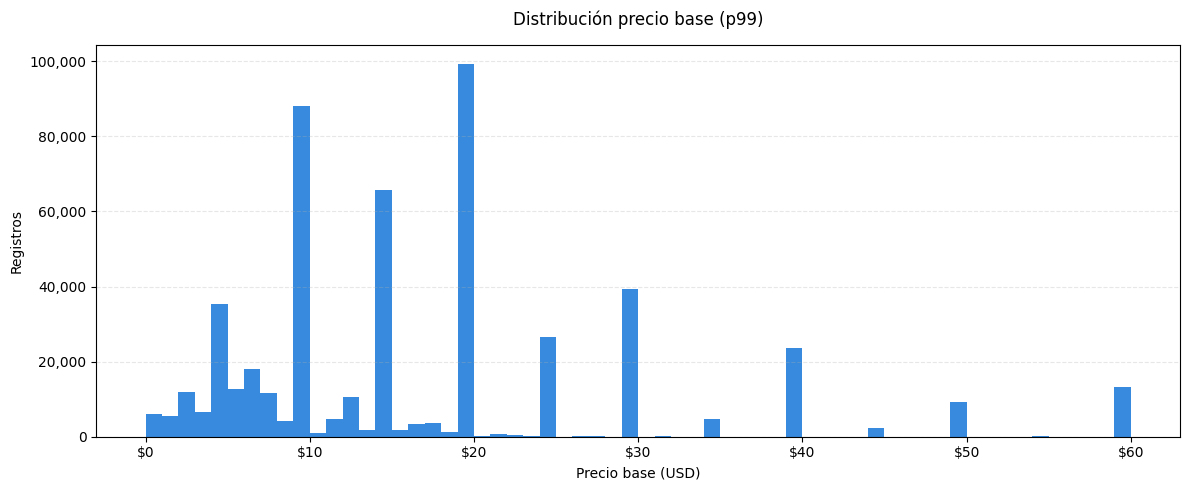

In [31]:
titulo = 'Distribución precio base (p99)'
p99 = df_hist['precio_base'].quantile(0.99)
datos = df_hist.loc[df_hist['precio_base'] <= p99, 'precio_base']

plt.figure(figsize=(12, 5))
plt.hist(datos, bins=60, color='#378ADD', edgecolor='none')
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Precio base (USD)')
plt.ylabel('Registros')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}'))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()


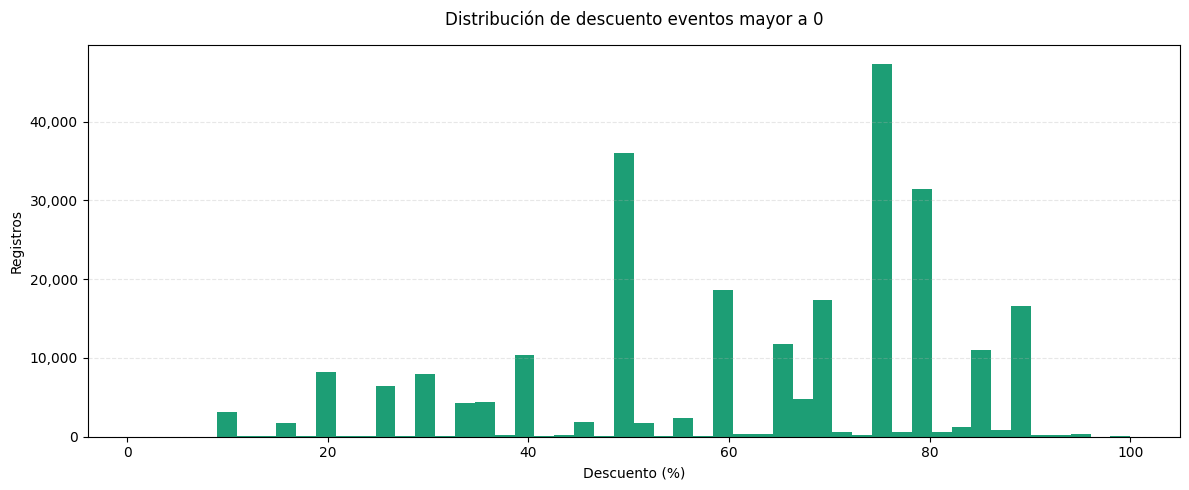

In [32]:
titulo = 'Distribución de descuento eventos mayor a 0'
desc_pos = df_hist.loc[df_hist['descuento'] > 0, 'descuento']

plt.figure(figsize=(12, 5))
plt.hist(desc_pos, bins=50, color='#1D9E75', edgecolor='none')
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Descuento (%)')
plt.ylabel('Registros')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()


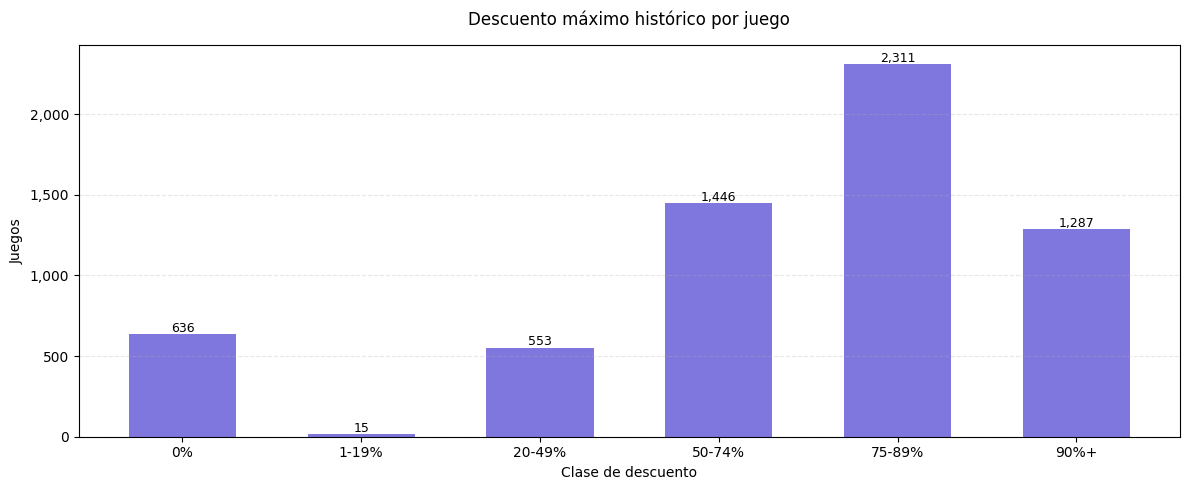

In [33]:
titulo = 'Descuento máximo histórico por juego'

plt.figure(figsize=(12, 5))
plt.bar(dist.index, dist.values, color='#7F77DD', width=0.6)
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Clase de descuento')
plt.ylabel('Juegos')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, (lab, v) in enumerate(dist.items()):
    plt.text(i, v + 15, f'{v:,}', ha='center', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()


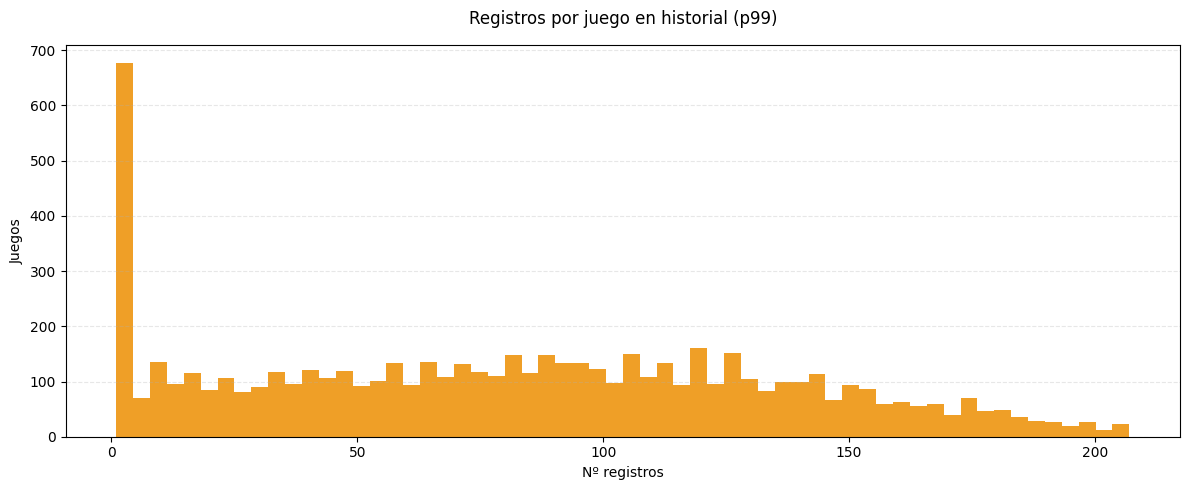

In [34]:
titulo = 'Registros por juego en historial (p99)'
regs_por_juego = df_hist.groupby('itad_id_texto').size()
p99r = regs_por_juego.quantile(0.99)

plt.figure(figsize=(12, 5))
plt.hist(regs_por_juego[regs_por_juego <= p99r], bins=60, color='#EF9F27', edgecolor='none')
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Nº registros')
plt.ylabel('Juegos')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()


## analisis temportal

In [35]:
df_hist['anio'] = df_hist['fecha'].dt.year
df_hist['mes'] = df_hist['fecha'].dt.month
df_hist['anio_mes'] = df_hist['fecha'].dt.to_period('M')
df_hist['semana'] = df_hist['fecha'].dt.isocalendar().week.astype(int)

In [36]:
df_hist

,itad_id_texto,precio_base,precio,descuento,fecha_unix,fecha,anio,mes,anio_mes,semana
0,018d937f-03e2-7281-a961-037a2d279a92,59.99,59.99,0,1741090525,2025-03-04 12:15:25,2025,3,2025-03,10
1,018d937f-03e2-7281-a961-037a2d279a92,29.99,29.99,0,1609872559,2021-01-05 18:49:19,2021,1,2021-01,1
2,018d937f-03e2-7281-a961-037a2d279a92,29.99,14.99,50,1608662061,2020-12-22 18:34:21,2020,12,2020-12,52
3,018d937f-03e2-7281-a961-037a2d279a92,29.99,29.99,0,1606847026,2020-12-01 18:23:46,2020,12,2020-12,49
4,018d937f-03e2-7281-a961-037a2d279a92,29.99,14.99,50,1606328860,2020-11-25 18:27:40,2020,11,2020-11,48
...,...,...,...,...,...,...,...,...,...,...
516030,018d937f-0998-7216-a664-200759cfec96,9.99,9.99,0,1471293922,2016-08-15 20:45:22,2016,8,2016-08,33
516031,018d937f-0998-7216-a664-200759cfec96,9.99,1.99,80,1470685527,2016-08-08 19:45:27,2016,8,2016-08,32
516032,018d937f-0998-7216-a664-200759cfec96,9.99,9.99,0,1467649526,2016-07-04 16:25:26,2016,7,2016-07,27
516033,018d937f-0998-7216-a664-200759cfec96,9.99,1.99,80,1466708003,2016-06-23 18:53:23,2016,6,2016-06,25


## Registros por año

In [37]:
print(":")
print(df_hist.groupby('anio').size().to_string())
#una buena distribucion

:
anio
2016    21311
2017    28414
2018    35822
2019    45357
2020    50307
2021    53280
2022    54475
2023    60140
2024    69817
2025    73209
2026    23903


## Tasa de descuento por mes del año

In [38]:
desc_por_mes = (df_hist.groupby('mes')
                .agg(total=('descuento', 'count'),
                     con_desc=('descuento', lambda x: (x > 0).sum()))
                .assign(tasa=lambda d: (100 * d['con_desc'] / d['total']).round(1)))
print("Tasa de descuento por mes:")
print(desc_por_mes[['total', 'con_desc', 'tasa']].to_string())
#la estacionalidad es clara Junio al 78.6% es la Summer Sale de Steam,
#  diciembre al 66.2% es la Winter Sale, 
# octubre al 61% es la Halloween/Autumn Sale. 
# Todo tiene sentido

Tasa de descuento por mes:
     total  con_desc  tasa
mes                       
1    59766     15518 26.00
2    39037     17875 45.80
3    52838     26147 49.50
4    23412     12638 54.00
5    25045     11470 45.80
6    47700     37479 78.60
7    47431      8191 17.30
8    22929     10965 47.80
9    29270     16312 55.70
10   36479     22242 61.00
11   72045     35861 49.80
12   60083     39765 66.20


In [39]:
desc_por_semana = (df_hist[df_hist['descuento'] > 0]
                   .groupby('semana')['descuento']
                   .mean().round(1))
print(desc_por_semana.sort_values(ascending=False).head(50).to_string())
# de buenas a primera no veo un patron en las semanas

semana
9    64.30
50   64.30
3    64.20
24   64.20
30   64.20
40   63.60
8    63.60
2    63.40
49   63.40
10   63.40
1    63.30
36   63.30
15   63.20
21   63.20
41   63.10
12   63.00
34   62.90
11   62.90
5    62.80
25   62.70
29   62.70
51   62.70
46   62.50
26   62.50
48   62.40
32   62.40
14   62.30
22   62.30
23   62.30
16   62.30
52   62.20
38   62.10
20   62.10
4    62.00
37   61.90
42   61.80
28   61.70
33   61.70
31   61.60
47   61.40
45   61.30
17   61.30
6    61.30
19   61.30
39   61.20
35   61.20
7    61.10
13   61.10
18   61.00
44   60.80


## Graficas

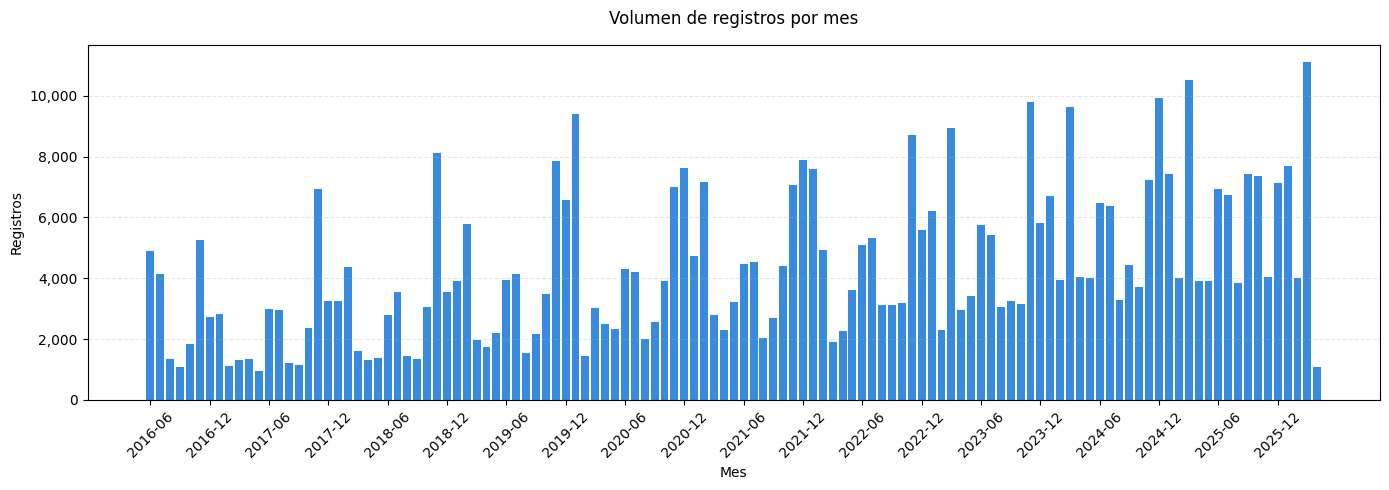

In [40]:
titulo = 'Volumen de registros por mes'
por_mes = df_hist.groupby('anio_mes').size().reset_index(name='registros')
por_mes['anio_mes_str'] = por_mes['anio_mes'].astype(str)

plt.figure(figsize=(14, 5))
plt.bar(range(len(por_mes)), por_mes['registros'], color='#378ADD', width=0.8)
plt.xticks(
    ticks=range(0, len(por_mes), 6),
    labels=por_mes['anio_mes_str'].iloc[::6],
    rotation=45
)
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Mes')
plt.ylabel('Registros')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()


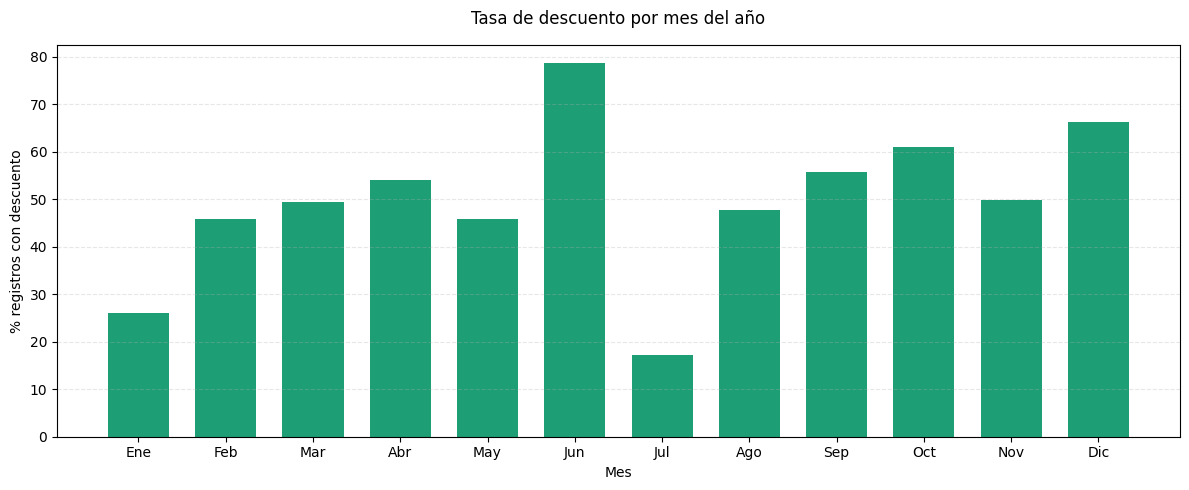

In [41]:
titulo = 'Tasa de descuento por mes del año'
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

plt.figure(figsize=(12, 5))
plt.bar(range(1, 13), desc_por_mes['tasa'], color='#1D9E75', width=0.7)
plt.xticks(range(1, 13), meses)
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Mes')
plt.ylabel('% registros con descuento')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()


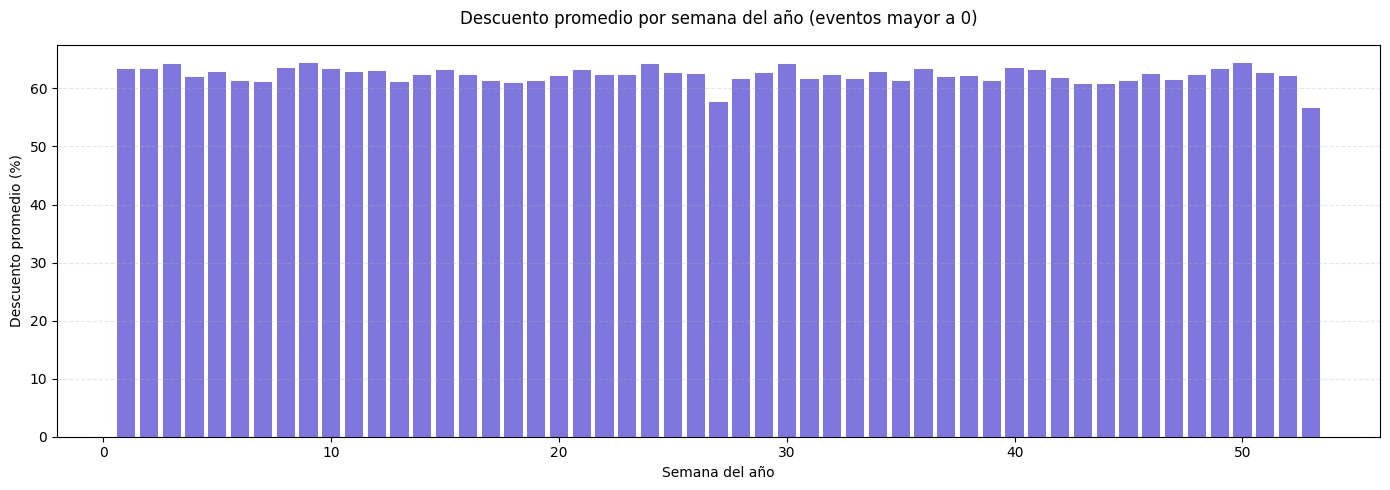

In [42]:
titulo = 'Descuento promedio por semana del año (eventos mayor a 0)'

plt.figure(figsize=(14, 5))
plt.bar(desc_por_semana.index, desc_por_semana.values, color='#7F77DD', width=0.8)
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Semana del año')
plt.ylabel('Descuento promedio (%)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()


## valores actuales

In [43]:
df_actuales

,itad_id_texto,precio_actual,precio_minimo,fecha_minimo,en_bundle,fecha_actualizacion,descuento_actual,expiry
0,018d937f-03e2-7281-a961-037a2d279a92,NaN,NaN,NaN,0,1775855678,NaN,NaN
1,018d937f-1212-7232-b23f-a046f6fd4a57,39.99,3.99,1774545537.00,0,1775855680,0.00,NaN
2,018d937f-21e1-728e-86d7-9acb3c59f2bb,9.99,0.99,1774545492.00,0,1775855682,0.00,NaN
3,018d937f-2b23-73a3-9b40-d93860065d00,NaN,NaN,NaN,0,1775855684,NaN,NaN
4,018d937e-f829-73ff-aa7f-95421948da6b,NaN,NaN,NaN,0,1775855686,NaN,NaN
...,...,...,...,...,...,...,...,...
6384,018d937f-35ad-703d-b17c-09af001dda54,NaN,NaN,NaN,0,1775867231,NaN,NaN
6385,01939824-f7b2-7183-8ad2-5e836a78cebb,9.99,3.39,1774545988.00,0,1775867233,0.00,NaN
6386,018d937f-0c8e-70ea-a7db-dcfb5bca292a,5.99,0.89,1774545789.00,0,1775867234,0.00,NaN
6387,018d937f-24bf-70b0-9bff-ba584344516a,6.99,1.39,1774545495.00,0,1775867236,0.00,NaN


In [44]:
df_actuales.isnull().sum()


itad_id_texto             0
precio_actual           765
precio_minimo          1212
fecha_minimo            765
en_bundle                 0
fecha_actualizacion       0
descuento_actual        765
expiry                 5712
dtype: int64

In [45]:
100*df_actuales.isnull().mean()
#muchos de expiracion en 89 porque no estan en oferta ahora mismo

itad_id_texto          0.00
precio_actual         11.97
precio_minimo         18.97
fecha_minimo          11.97
en_bundle              0.00
fecha_actualizacion    0.00
descuento_actual      11.97
expiry                89.40
dtype: float64

In [46]:
df_actuales['fecha_actualizacion'] = pd.to_datetime(df_actuales['fecha_actualizacion'], unit='s', errors='coerce')
df_actuales['fecha_minimo'] = pd.to_datetime(df_actuales['fecha_minimo'], unit='s', errors='coerce')
df_actuales['expiry'] = pd.to_datetime(df_actuales['expiry'], unit='s', errors='coerce')

In [47]:
df_actuales

,itad_id_texto,precio_actual,precio_minimo,fecha_minimo,en_bundle,fecha_actualizacion,descuento_actual,expiry
0,018d937f-03e2-7281-a961-037a2d279a92,NaN,NaN,NaT,0,2026-04-10 21:14:38,NaN,NaT
1,018d937f-1212-7232-b23f-a046f6fd4a57,39.99,3.99,2026-03-26 17:18:57,0,2026-04-10 21:14:40,0.00,NaT
2,018d937f-21e1-728e-86d7-9acb3c59f2bb,9.99,0.99,2026-03-26 17:18:12,0,2026-04-10 21:14:42,0.00,NaT
3,018d937f-2b23-73a3-9b40-d93860065d00,NaN,NaN,NaT,0,2026-04-10 21:14:44,NaN,NaT
4,018d937e-f829-73ff-aa7f-95421948da6b,NaN,NaN,NaT,0,2026-04-10 21:14:46,NaN,NaT
...,...,...,...,...,...,...,...,...
6384,018d937f-35ad-703d-b17c-09af001dda54,NaN,NaN,NaT,0,2026-04-11 00:27:11,NaN,NaT
6385,01939824-f7b2-7183-8ad2-5e836a78cebb,9.99,3.39,2026-03-26 17:26:28,0,2026-04-11 00:27:13,0.00,NaT
6386,018d937f-0c8e-70ea-a7db-dcfb5bca292a,5.99,0.89,2026-03-26 17:23:09,0,2026-04-11 00:27:14,0.00,NaT
6387,018d937f-24bf-70b0-9bff-ba584344516a,6.99,1.39,2026-03-26 17:18:15,0,2026-04-11 00:27:16,0.00,NaT


In [48]:
print(f"Juegos en Datos_Actuales_ITAD : {len(df_actuales):,}")
print(f"Con descuento_actual > 0 : {(df_actuales['descuento_actual'] > 0).sum():,}  ({100*(df_actuales['descuento_actual'] > 0).mean():.1f}%)")
print(f"Con expiry definido : {df_actuales['expiry'].notna().sum():,}  ({100*df_actuales['expiry'].notna().mean():.1f}%)")

Juegos en Datos_Actuales_ITAD : 6,389
Con descuento_actual > 0 : 677  (10.6%)
Con expiry definido : 677  (10.6%)


## precio_actual

In [49]:
df_actuales['precio_actual'].describe().round(2)

count   5624.00
mean      15.73
std       14.48
min        0.00
25%        4.99
50%       12.49
75%       19.99
max      280.00
Name: precio_actual, dtype: float64

## precio_minimo

In [50]:
df_actuales['precio_minimo'].describe().round(2)

count   5177.00
mean       5.66
std        7.07
min        0.05
25%        1.49
50%        2.99
75%        6.99
max       86.38
Name: precio_minimo, dtype: float64

## descuento_actual

In [51]:
df_actuales['descuento_actual'].describe().round(2)

count   5624.00
mean       8.11
std       22.91
min        0.00
25%        0.00
50%        0.00
75%        0.00
max      100.00
Name: descuento_actual, dtype: float64

## juegos catuales en minimo historico

In [52]:
df_actuales['en_minimo'] = (df_actuales['precio_actual'] <= df_actuales['precio_minimo'] * 1.01).astype(int)
print(f" {df_actuales['en_minimo'].sum():,}  ({100*df_actuales['en_minimo'].mean():.1f}%)")

 517  (8.1%)


## hay juegos con 100 de descuento

In [53]:
df_actuales['diff_vs_minimo'] = ((df_actuales['precio_actual'] - df_actuales['precio_minimo'])
                                  / df_actuales['precio_minimo'].replace(0, np.nan) * 100).round(1)
print("\ndiff precio_actual vs precio_minimo (%):")
print(df_actuales['diff_vs_minimo'].describe().round(2))


diff precio_actual vs precio_minimo (%):
count    5177.00
mean      404.30
std       508.90
min      -100.00
25%       100.10
50%       300.70
75%       569.20
max     15684.20
Name: diff_vs_minimo, dtype: float64


In [54]:
fp = (df_actuales[(df_actuales['precio_actual'] == 0) & (df_actuales['precio_minimo'] > 0)]
      .merge(df_juegos[['itad_id_texto', 'id_steam', 'titulo', 'steam_price_initial']], 
             on='itad_id_texto', how='left')
      [['titulo', 'id_steam', 'precio_actual', 'precio_minimo', 'steam_price_initial']])
print(f"Juegos con precio_actual=0 y mínimo>0: {len(fp)}")
print(fp.to_string())

# son juegos que en su momento estaban gratis y leugo se hcicieron gratis Life is Strange, Team Fortress 2

Juegos con precio_actual=0 y mínimo>0: 121
                                                    titulo  id_steam  precio_actual  precio_minimo  steam_price_initial
0                                          Life is Strange    319630           0.00           1.99                 0.00
1                                          Team Fortress 2       440           0.00          19.99                 0.00
2                                                   Dota 2       570           0.00           7.49                 0.00
3                                               The Sims 4   1222670           0.00           4.79                 0.00
4                                                Destiny 2   1085660           0.00          34.99                 0.00
5                                      PUBG: Battlegrounds    578080           0.00          14.99                 0.00
6                                        Rainbow Six Siege    359550           0.00           3.99                 0.

In [55]:
mask_fp = df_actuales['precio_actual'] == 0
print(f"Juegos F2P (precio_actual=0): {mask_fp.sum()}")
df_actuales.loc[mask_fp, 'precio_minimo'] = 0

Juegos F2P (precio_actual=0): 568


In [56]:
mask_fp.value_counts()

precio_actual
False    5821
True      568
Name: count, dtype: int64

In [57]:
#sin minimo historico
sin_min = df_actuales[df_actuales['precio_minimo'].isna()]
print(f"Sin precio_minimo: {len(sin_min)}")
print(sin_min['precio_actual'].describe().round(2))
print(f"Con precio_actual = 0: {(sin_min['precio_actual'] == 0).sum()}")
print(f"Con precio_actual > 0: {(sin_min['precio_actual'] > 0).sum()}")

Sin precio_minimo: 765
count   0.00
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: precio_actual, dtype: float64
Con precio_actual = 0: 0
Con precio_actual > 0: 0


In [58]:
sin_min = df_actuales[df_actuales['precio_minimo'].isna()].merge(
    df_juegos[['itad_id_texto', 'id_steam', 'titulo', 'steam_price_initial']],
    on='itad_id_texto', how='left'
)
print(f"Sin precio_minimo: {len(sin_min)}")
print(f"Con steam_price_initial > 0: {(sin_min['steam_price_initial'] > 0).sum()}")
print(f"Con steam_price_initial = 0: {(sin_min['steam_price_initial'] == 0).sum()}")
print(f"Con steam_price_initial nulo: {sin_min['steam_price_initial'].isna().sum()}")
print(sin_min[['titulo', 'id_steam', 'precio_actual', 'precio_minimo', 'steam_price_initial']].to_string())

Sin precio_minimo: 765
Con steam_price_initial > 0: 168
Con steam_price_initial = 0: 537
Con steam_price_initial nulo: 60
                                                                            titulo  id_steam  precio_actual  precio_minimo  steam_price_initial
0                                                               Grand Theft Auto V    271590            NaN            NaN                 0.00
1                                                      The Elder Scrolls V: Skyrim     72850            NaN            NaN               359.00
2                                                    Grand Theft Auto: San Andreas     12120            NaN            NaN                 0.00
3                                                      Grand Theft Auto: Vice City     12110            NaN            NaN                 0.00
4                                                              Batman: Arkham City     57400            NaN            NaN                 0.00
5             

In [59]:
itad_sin_precio = set(df_actuales[df_actuales['precio_actual'].isna()]['itad_id_texto'])
#itad_sin_precio

In [60]:
con_hist = df_hist[df_hist['itad_id_texto'].isin(itad_sin_precio)]
print(f"se tiene de historial: {con_hist['itad_id_texto'].nunique()}")

se tiene de historial: 627


In [61]:
# prueba de uno detectado
df_juegos[df_juegos['titulo'].str.contains('Assassin', case=False, na=False)][['juego_id', 'id_steam', 'titulo', 'itad_id_texto', 'steam_price_initial']]

,juego_id,id_steam,titulo,itad_id_texto,steam_price_initial
10,11,33230,Assassin's Creed II,018d937f-3497-71d8-91b5-442e6b36f0cd,399.00
32,41,242050,Assassin's Creed IV Black Flag,018d937f-0602-72cd-b27e-1beaec4b9f6f,799.00
36,45,48190,Assassin's Creed Brotherhood,018d937f-0e82-70e5-ac00-0d05a4abc342,399.00
51,65,208480,Assassin's Creed III,018d937e-e9d4-7075-a482-728448f8f0fc,0.00
62,79,201870,Assassin's Creed Revelations,018d937f-0085-7156-93a8-5a7c9a7854cf,399.00
81,101,582160,Assassin's Creed Origins,018d937f-246a-7339-8ccc-7bddae738345,1199.00
101,128,289650,Assassin's Creed Unity,018d937e-f54c-7379-a57f-9ab6cdc42d20,599.00
102,129,812140,Assassin's Creed Odyssey,018d937f-0184-7248-8d64-3c723c523111,1199.00
120,160,368500,Assassin's Creed Syndicate,018d937e-fdd8-73fc-b6f2-669d6969f960,599.00
184,238,311560,Assassin's Creed Rogue,018d937e-f9bd-732a-8129-55703fce0e08,399.00


Se encontro el problema, al momento usar la api de itad uso el id para obtener el juego, pero esos juego ya no se venden por separado y viene normalemnte dentro de paquetes, itad regreso la informacion del juego original pero en steam ya no se venede solo, se vende en un paquete que ya tiene otro historial péro el id lo asocio. Entoncesmisma id pero diferente infroamcion en cada paltaforma estos se tiene que rellamar y revisar pero de momento se tendran que omitir

In [62]:
itad_sin_precio = set(df_actuales[df_actuales['precio_actual'].isna()]['itad_id_texto'])

In [63]:

juego_ids_sin_precio = set(df_juegos[df_juegos['itad_id_texto'].isin(itad_sin_precio)]['juego_id'])

df_juegos = df_juegos[~df_juegos['itad_id_texto'].isin(itad_sin_precio)].reset_index(drop=True)
df_hist = df_hist[~df_hist['itad_id_texto'].isin(itad_sin_precio)].reset_index(drop=True)
df_actuales= df_actuales[~df_actuales['itad_id_texto'].isin(itad_sin_precio)].reset_index(drop=True)
df_reviews= df_reviews[~df_reviews['juego_id'].isin(juego_ids_sin_precio)].reset_index(drop=True)
df_generos= df_generos[~df_generos['juego_id'].isin(juego_ids_sin_precio)].reset_index(drop=True)
df_etiquetas = df_etiquetas[~df_etiquetas['juego_id'].isin(juego_ids_sin_precio)].reset_index(drop=True)
df_modos= df_modos[~df_modos['juego_id'].isin(juego_ids_sin_precio)].reset_index(drop=True)

print(f"df_juegos: {len(df_juegos):,}")
print(f"df_hist: {len(df_hist):,}")
print(f"df_actuales : {len(df_actuales):,}")
print(f"df_reviews : {len(df_reviews):,}")

df_juegos: 5,634
df_hist: 492,906
df_actuales : 5,624
df_reviews : 506,676


## -Graficas

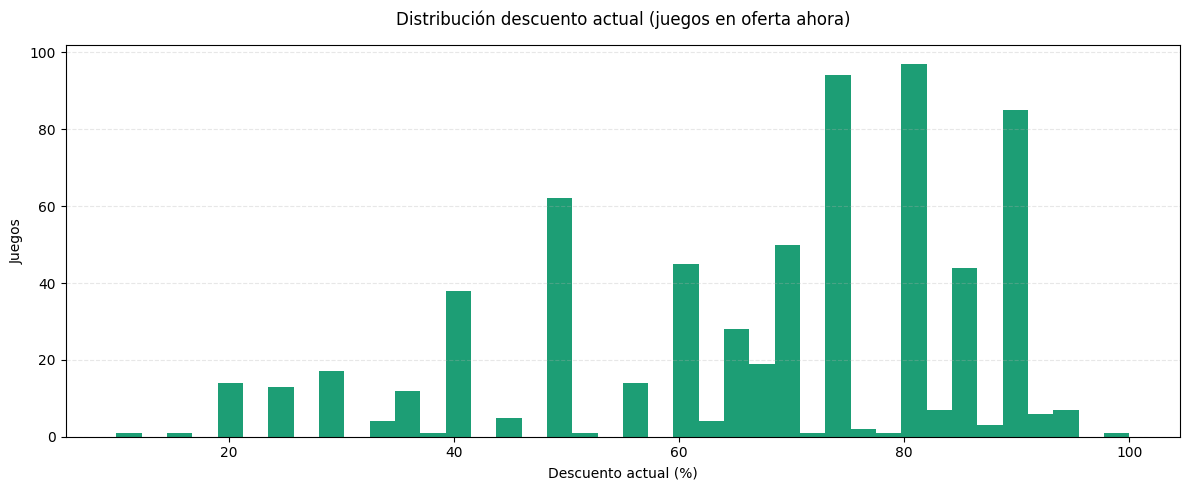

In [64]:
titulo = 'Distribución descuento actual (juegos en oferta ahora)'
desc_ahora = df_actuales[df_actuales['descuento_actual'] > 0]['descuento_actual']

plt.figure(figsize=(12, 5))
plt.hist(desc_ahora, bins=40, color='#1D9E75', edgecolor='none')
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Descuento actual (%)')
plt.ylabel('Juegos')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()


In [65]:
hoy = pd.Timestamp.now()

In [66]:
(hoy - df_actuales['fecha_minimo']).dt.days

0       18
1       18
2       18
3        4
4       18
        ..
5619    18
5620    18
5621    18
5622    18
5623    18
Name: fecha_minimo, Length: 5624, dtype: int64

In [67]:
df_actuales['dias_desde_minimo'] = (hoy - df_actuales['fecha_minimo']).dt.days

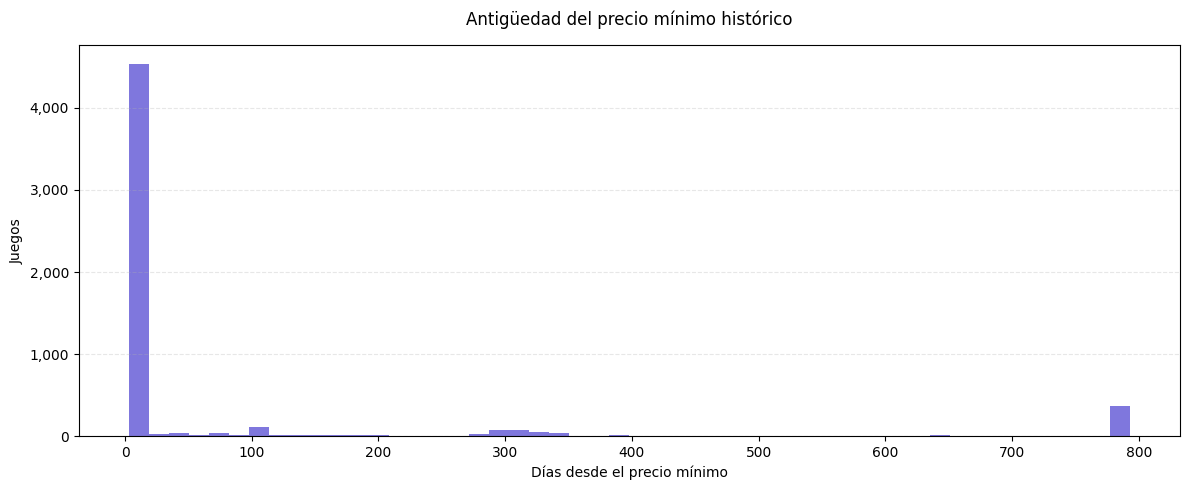

In [68]:
titulo = 'Antigüedad del precio mínimo histórico'
hoy = pd.Timestamp.now()
df_actuales['dias_desde_minimo'] = (hoy - df_actuales['fecha_minimo']).dt.days
dias = df_actuales['dias_desde_minimo'].dropna()
dias = dias[dias <= dias.quantile(0.99)]

plt.figure(figsize=(12, 5))
plt.hist(dias, bins=50, color='#7F77DD', edgecolor='none')
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Días desde el precio mínimo')
plt.ylabel('Juegos')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

#el pico gigante entre 0-30 días indica que ahce poco una serie de ofertas, posiblemnte de las spings sale

## decuentos y resenas

In [69]:
max_desc = (df_hist.groupby('itad_id_texto')
            .agg(
                desc_max=('descuento', 'max'),
                desc_avg=('descuento', 'mean'),
                n_eventos_desc=('descuento', lambda x: (x > 0).sum()),
                precio_base_med=('precio_base', 'median')
            ).reset_index())

reviews_agg = (df_reviews.groupby('juego_id')
               .agg(
                   total_resenas=('resena_id', 'count'),
                   pct_positivo=('recomendado', 'mean'),
                   avg_score_pond=('puntuacion_ponderada', 'mean'),
                   avg_minutos=('minutos_totales', 'median')
               ).reset_index()
               .assign(pct_positivo=lambda d: (d['pct_positivo'] * 100).round(2)))

df_corr = (df_juegos[['juego_id', 'itad_id_texto', 'titulo', 'puntuacion_igdb',
                       'conteo_votos_igdb', 'metacritic_score', 'fecha_lanzamiento',
                       'recommendations_count', 'achievements_count',
                       'conteo_dlc', 'steam_price_initial']]
           .merge(max_desc, on='itad_id_texto', how='left')
           .merge(reviews_agg, on='juego_id', how='left')
           .merge(df_generos, on='juego_id', how='left'))

In [70]:
df_corr['fecha_lanzamiento'] = pd.to_datetime(df_corr['fecha_lanzamiento'], errors='coerce')
df_corr['edad_dias'] = (pd.Timestamp.now() - df_corr['fecha_lanzamiento']).dt.days

In [71]:
print(f"Shape: {df_corr.shape}")
print(f"Nulos en desc_max: {df_corr['desc_max'].isna().sum()}")
print(df_corr[['desc_max', 'puntuacion_igdb', 'total_resenas', 'pct_positivo', 'edad_dias']].describe().round(2))

# EL SEGO POSITIVO SE MANITENE

Shape: (5634, 21)
Nulos en desc_max: 11
       desc_max  puntuacion_igdb  total_resenas  pct_positivo  edad_dias
count   5623.00          5634.00        4966.00       4966.00    5633.00
mean      65.38            71.37         102.03         88.69    3571.92
std       27.48            11.23         210.77         16.15    2571.37
min        0.00            10.27           1.00          0.00      14.00
25%       50.00            65.98           6.00         84.45    1680.00
50%       75.00            71.96          22.00         94.44    3120.00
75%       85.00            79.32          77.00        100.00    4632.00
max      100.00           100.00        1003.00        100.00   16540.00


In [72]:
cols_num = [
    'puntuacion_igdb', 'conteo_votos_igdb', 'metacritic_score',
    'recommendations_count', 'achievements_count', 'conteo_dlc',
    'steam_price_initial', 'total_resenas', 'pct_positivo',
    'avg_score_pond', 'avg_minutos', 'edad_dias', 'precio_base_med'
]

corr_pearson = {}
for col in cols_num:
    sub = df_corr[['desc_max', col]].dropna()
    r, p = stats.pearsonr(sub['desc_max'], sub[col])
    corr_pearson[col] = {'r': round(r, 3), 'p': round(p, 4), 'n': len(sub)}

df_corr_res = (pd.DataFrame(corr_pearson).T.sort_values('r', ascending=False))
print(df_corr_res.to_string())

# los dias que tiene le juego tien mucha relacioncon  decuentos mas agresivos
#  la relacion metatreric, pct, postivo, puntuacion de igdb
# p-value bajo nos dice que esos resultados no se deben al azar

                          r    p       n
edad_dias              0.26 0.00 5623.00
precio_base_med        0.23 0.00 5623.00
steam_price_initial    0.17 0.00 5616.00
conteo_votos_igdb      0.09 0.00 5623.00
puntuacion_igdb       -0.00 0.95 5623.00
recommendations_count -0.00 0.88 5616.00
conteo_dlc            -0.01 0.71 5623.00
achievements_count    -0.01 0.35 5616.00
avg_score_pond        -0.03 0.02 4965.00
total_resenas         -0.07 0.00 4965.00
pct_positivo          -0.08 0.00 4965.00
avg_minutos           -0.14 0.00 4965.00
metacritic_score      -0.20 0.00 2403.00


## graficas

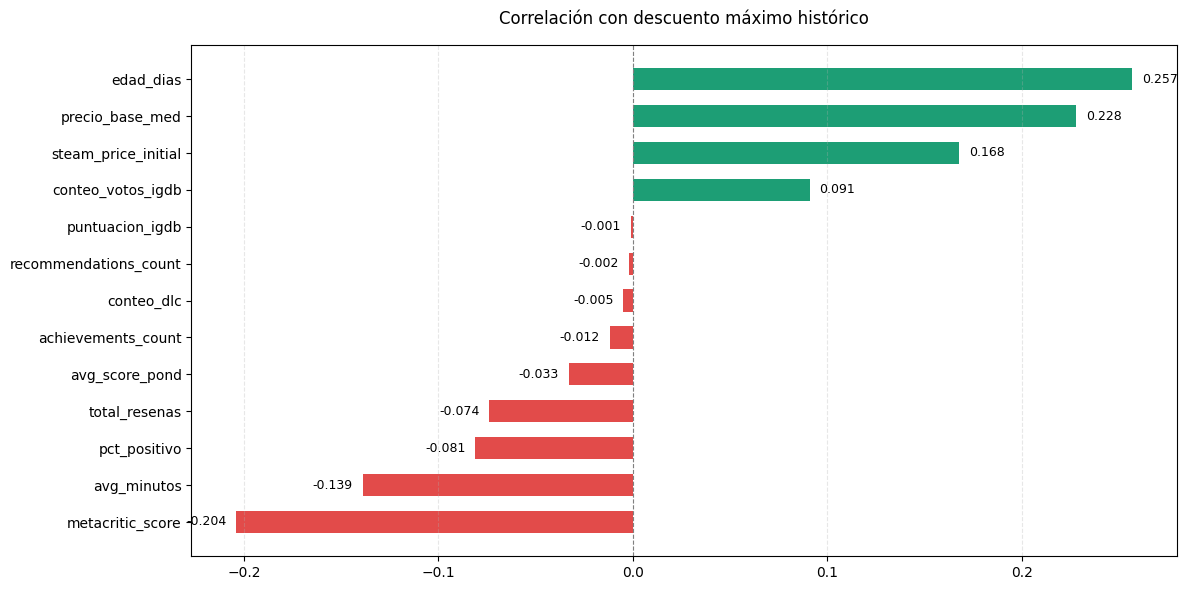

In [73]:
titulo = 'Correlación con descuento máximo histórico'
df_plot = df_corr_res.sort_values('r')
colores = ['#E24B4A' if r < 0 else '#1D9E75' for r in df_plot['r']]

plt.figure(figsize=(12, 6))
bars = plt.barh(df_plot.index, df_plot['r'], color=colores, height=0.6)
plt.axvline(0, color='gray', lw=0.8, ls='--')
plt.title(titulo, fontsize=12, pad=15)
for bar, (_, row) in zip(bars, df_plot.iterrows()):
    x = row['r']
    plt.text(x + (0.005 if x >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
             f"{x:.3f}", va='center', ha='left' if x >= 0 else 'right', fontsize=9)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()


Descuento máximo por género (mediana):
                            mean  median  count
genero                                         
Puzzle                     70.30   80.00   1347
Racing                     73.80   80.00    244
Real Time Strategy (RTS)   71.80   80.00    232
Platform                   70.90   80.00    807
Sport                      67.50   80.00    195
Point-and-click            68.00   76.00    519
Arcade                     68.20   75.00    589
Adventure                  67.10   75.00   3405
Indie                      64.60   75.00   3225
Fighting                   68.90   75.00    233
Hack and slash/Beat 'em up 68.00   75.00    342
Music                      63.90   75.00    100
Strategy                   66.90   75.00   1324
Role-playing (RPG)         63.30   75.00   1566
Shooter                    67.80   75.00   1042
Simulator                  63.90   75.00   1317
Turn-based strategy (TBS)  68.40   75.00    312
Tactical                   67.70   75.00    304
C

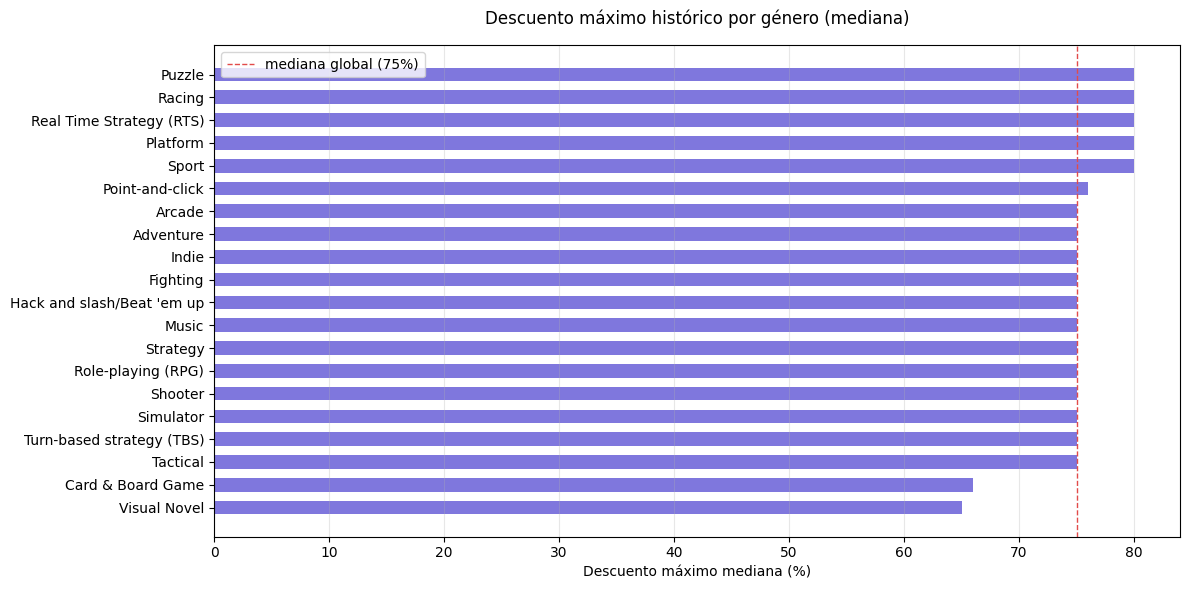

In [74]:
df_gen_exp = (df_corr[['juego_id', 'desc_max', 'generos']].dropna(subset=['generos'])
              .assign(genero=lambda d: d['generos'].str.split('|'))
              .explode('genero'))

desc_por_genero = (df_gen_exp.groupby('genero')['desc_max']
                   .agg(['mean', 'median', 'count'])
                   .query('count >= 50')
                   .sort_values('median', ascending=False)
                   .round(1))

print("Descuento máximo por género (mediana):")
print(desc_por_genero.to_string())

titulo = 'Descuento máximo histórico por género (mediana)'
plt.figure(figsize=(12, 6))
plt.barh(desc_por_genero.index[::-1], desc_por_genero['median'][::-1],
         color='#7F77DD', height=0.6)
plt.axvline(df_corr['desc_max'].median(), color='#E24B4A',
            lw=1, ls='--', label=f"mediana global ({df_corr['desc_max'].median():.0f}%)")
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Descuento máximo mediana (%)')
plt.legend()
plt.grid(axis='x', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()


  rango_precio  median  count
0         $0-5   40.00   1101
1        $5-10   80.00   1239
2       $10-20   77.00   1848
3       $20-30   75.00    752
4       $30-50   75.00    470
5         $50+   67.00    213


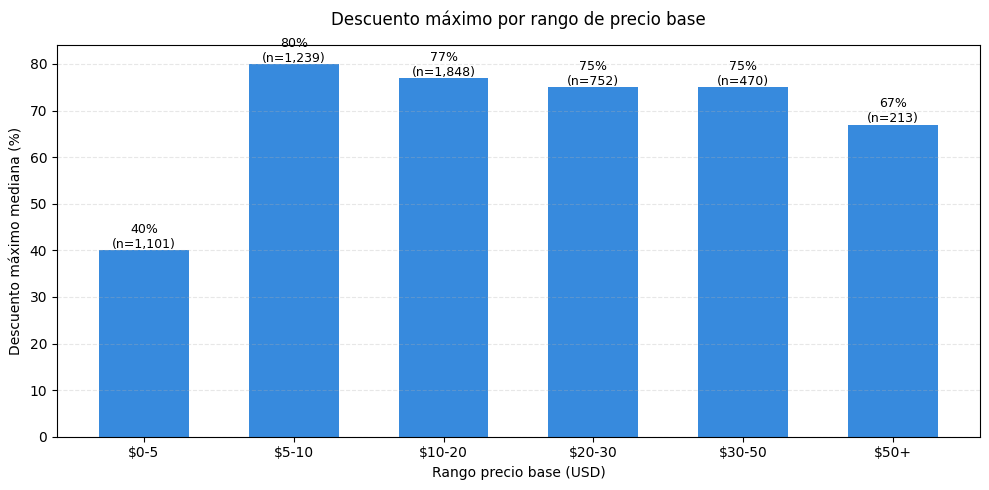

In [75]:
titulo = 'Descuento máximo por rango de precio base'
bins = [0, 5, 10, 20, 30, 50, 500]
labs = ['$0-5', '$5-10', '$10-20', '$20-30', '$30-50', '$50+']
df_corr['rango_precio'] = pd.cut(df_corr['precio_base_med'], bins=bins, labels=labs, right=False)

desc_precio = (df_corr.groupby('rango_precio', observed=True)['desc_max']
               .agg(['median', 'count']).reset_index())
print(desc_precio.to_string())

plt.figure(figsize=(10, 5))
plt.bar(desc_precio['rango_precio'].astype(str), desc_precio['median'],
        color='#378ADD', width=0.6)
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Rango precio base (USD)')
plt.ylabel('Descuento máximo mediana (%)')
for i, row in desc_precio.iterrows():
    plt.text(i, row['median'] + 0.5, f"{row['median']:.0f}%\n(n={row['count']:,})",
             ha='center', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

# los de $50 bajan a 67%. Los juegos más caros descuentan menos agresivamente

# Notas de EDA

- se me fue hltb_idINTEGER
- lade tiempo de comletar tomaran un tiempo en llenarse
- metatric score solo un tercio llena
-  steam_languages,achievements_count,steam_discount_percent son casi 1 tercio nuos pero puede deberse aque no todos lo juegos estan en staeam ya que concide mas o menos con id_steam 
- el valor dematric esta mas lleno, nos servira
- El catálogo está dominado por juegos principales
- El pico de lanzamientos fue 2015-2019, con caída visible en 2020-2022 que es clara apndemia y recuperación en 2023-2024 pero 2025 volvio a bajar
- sis e cumplio que nos tarajo al menos 10 años de datos
- se tiene como precio maximo de 80000 que es claramente un error, se jsto opor que si fue un error de la base
- la estacionalidad es notable Junio al 78.6% es la Summer Sale de Steam,diciembre al 66.2% es la Winter Sale, octubre al 61% es la Halloween/Autumn Sale. Todo tiene sentido
- se ve un  congelamiento en julio depues de las ofertas de junio, en Enero bajo también por el mismo efecto de las ventas de invierno.
- Las desemana no dicen mucho, pero es curiosos que mantenga constante el promedio, es como si steam supiera cuantos porcentajes de edsceunto hacer
- actualemntwe los decusntos de 75%, 80% y 85% son los mas activos
- el pico gigante entre 0-30 días indica que ahce poco una serie de ofertas, posiblemnte de las spings sale
- los de $50 bajan a 67%. Los juegos más caros descuentan menos agresivamente

# ingenieria de variables

In [76]:
print(f"CAT_Juego con id_steam: {len(df_juegos):,}")
print(f"Hist_Precios_ITAD : {len(df_hist):,}")
print(f"Datos_Actuales_ITAD : {len(df_actuales):,}")
print(f"Hist_Steam_Reviews : {len(df_reviews):,}")
print(f"itad_ids con historial : {df_hist['itad_id_texto'].nunique():,}")
print(f"juego_ids con reseñas : {df_reviews['juego_id'].nunique():,}")
print(f"juevos dlc :{len(df_dlcs):,}")

CAT_Juego con id_steam: 5,634
Hist_Precios_ITAD : 492,906
Datos_Actuales_ITAD : 5,624
Hist_Steam_Reviews : 506,676
itad_ids con historial : 5,621
juego_ids con reseñas : 4,966
juevos dlc :1,367


In [77]:
conexion = sqlite3.connect(DB_PATH)
tablas = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%';", conexion)
resumen = []
for tabla in tablas['name']:
    cantidad = pd.read_sql_query(f"SELECT COUNT(*) as Cantidad FROM {tabla};", conexion).iloc[0,0]
    resumen.append({'Nombre': tabla, 'Cantidad': cantidad})
df = pd.DataFrame(resumen).sort_values(by='Cantidad', ascending=False)
display(df)

conexion.close()

,Nombre,Cantidad
20,Hist_Steam_Reviews,600194
21,Hist_Precios_ITAD,581162
17,REL_Juego_Etiqueta,127396
19,REL_Juegos_Similares,101550
18,REL_Juego_Plataforma,38040
10,REL_Juego_Genero,27717
11,REL_Juego_Tematica,21669
12,REL_Juego_Modo,17180
15,REL_Juego_Editor,14017
14,REL_Juego_Desarrollador,11338


In [78]:
df_hist_ordenado = df_hist.sort_values(['itad_id_texto', 'fecha']).reset_index(drop=True)

## Rellenar cada 7 dias desde que se detecto un cambio

In [79]:
def rellenar_cada_7_dias(group):
    group = group.sort_values('fecha').reset_index(drop=True)
    filas_extra = []
    
    for i in range(len(group) - 1):
        fecha_actual= group.loc[i, 'fecha']
        fecha_siguiente = group.loc[i+1, 'fecha']
        descuento_actual = group.loc[i, 'descuento']
        precio_actual= group.loc[i, 'precio']
        precio_base= group.loc[i, 'precio_base']
        itad_id= group.loc[i, 'itad_id_texto']
        
        fecha_iter = fecha_actual + pd.Timedelta(days=7)
        while fecha_iter < fecha_siguiente:
            filas_extra.append({
                'itad_id_texto' : itad_id,
                'precio_base': precio_base,
                'precio' : precio_actual,
                'descuento' : descuento_actual,
                'fecha' : fecha_iter,
                'anio' : fecha_iter.year,
                'mes': fecha_iter.month,
                'anio_mes': fecha_iter.to_period('M'),
                'semana': fecha_iter.isocalendar().week,
                'sintetico': 1
            })
            fecha_iter += pd.Timedelta(days=7)
    
    return filas_extra

In [80]:
todas_extras = []
for itad_id, group in df_hist_ordenado.groupby('itad_id_texto'):
    group_copy = group.copy().reset_index(drop=True)
    group_copy['itad_id_texto'] = itad_id
    extras = rellenar_cada_7_dias(group_copy)
    todas_extras.extend(extras)

df_hist_ordenado['sintetico'] = 0
df_sintetico = pd.DataFrame(todas_extras)

df_expandido = (pd.concat([df_hist_ordenado, df_sintetico], ignore_index=True)
                .sort_values(['itad_id_texto', 'fecha'])
                .reset_index(drop=True))

print(f"Filas originales : {len(df_hist_ordenado):,}")
print(f"Filas sintéticas : {len(df_sintetico):,}")
print(f"Total expandido : {len(df_expandido):,}")

Filas originales : 492,906
Filas sintéticas : 1,572,198
Total expandido : 2,065,104


In [81]:
THRESHOLD   = 20
WINDOW_DIAS = 7

def calcular_label(group):
    group = group.sort_values('fecha').reset_index(drop=True)
    fechas     = group['fecha'].values
    descuentos = group['descuento'].values
    labels = []
    for i in range(len(fechas)):
        limite = fechas[i] + np.timedelta64(WINDOW_DIAS, 'D')
        mask   = (fechas > fechas[i]) & (fechas <= limite)
        labels.append(int((descuentos[mask] >= THRESHOLD).any()))
    group['label'] = labels
    return group




In [82]:
resultados = []
for itad_id, group in df_expandido.groupby('itad_id_texto'):
    group_copy = group.copy()
    group_copy = calcular_label(group_copy)
    group_copy['itad_id_texto'] = itad_id
    resultados.append(group_copy)

df_expandido = pd.concat(resultados, ignore_index=True)

In [83]:
df_expandido.head(50)

,itad_id_texto,precio_base,precio,descuento,fecha_unix,fecha,anio,mes,anio_mes,semana,sintetico,label
0,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,1600780031.00,2020-09-22 13:07:11,2020,9,2020-09,39,0,0
1,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,NaN,2020-09-29 13:07:11,2020,9,2020-09,40,1,0
2,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,NaN,2020-10-06 13:07:11,2020,10,2020-10,41,1,0
3,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,NaN,2020-10-13 13:07:11,2020,10,2020-10,42,1,0
4,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,NaN,2020-10-20 13:07:11,2020,10,2020-10,43,1,0
5,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,NaN,2020-10-27 13:07:11,2020,10,2020-10,44,1,0
6,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,NaN,2020-11-03 13:07:11,2020,11,2020-11,45,1,0
7,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,NaN,2020-11-10 13:07:11,2020,11,2020-11,46,1,0
8,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,NaN,2020-11-17 13:07:11,2020,11,2020-11,47,1,0
9,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,NaN,2020-11-24 13:07:11,2020,11,2020-11,48,1,1


In [84]:
df_expandido.drop(columns='fecha_unix',inplace=True)

In [85]:
df_expandido.head()


,itad_id_texto,precio_base,precio,descuento,fecha,anio,mes,anio_mes,semana,sintetico,label
0,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-09-22 13:07:11,2020,9,2020-09,39,0,0
1,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-09-29 13:07:11,2020,9,2020-09,40,1,0
2,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-06 13:07:11,2020,10,2020-10,41,1,0
3,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-13 13:07:11,2020,10,2020-10,42,1,0
4,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-20 13:07:11,2020,10,2020-10,43,1,0


In [86]:
hoy = df_expandido['fecha'].max()

In [87]:
hoy

Timestamp('2026-04-10 18:15:26')

## variabels de ventas fuertes

In [88]:
df_expandido['es_junio']= (df_expandido['mes'] == 6).astype(int)
df_expandido['es_diciembre'] = (df_expandido['mes'] == 12).astype(int)

In [89]:
df_expandido.head(20)

,itad_id_texto,precio_base,precio,descuento,fecha,anio,mes,anio_mes,semana,sintetico,label,es_junio,es_diciembre
0,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-09-22 13:07:11,2020,9,2020-09,39,0,0,0,0
1,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-09-29 13:07:11,2020,9,2020-09,40,1,0,0,0
2,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-06 13:07:11,2020,10,2020-10,41,1,0,0,0
3,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-13 13:07:11,2020,10,2020-10,42,1,0,0,0
4,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-20 13:07:11,2020,10,2020-10,43,1,0,0,0
5,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-27 13:07:11,2020,10,2020-10,44,1,0,0,0
6,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-11-03 13:07:11,2020,11,2020-11,45,1,0,0,0
7,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-11-10 13:07:11,2020,11,2020-11,46,1,0,0,0
8,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-11-17 13:07:11,2020,11,2020-11,47,1,0,0,0
9,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-11-24 13:07:11,2020,11,2020-11,48,1,1,0,0


## dias para la siguiente sale grande

In [90]:
def dias_para_mes(fecha, mes_objetivo):
    año = fecha.year
    objetivo = pd.Timestamp(year=año, month=mes_objetivo, day=1)
    if fecha.month == mes_objetivo:
        return 0
    if fecha >= objetivo:
        objetivo = pd.Timestamp(year=año+1, month=mes_objetivo, day=1)
    return (objetivo - fecha).days

In [91]:
df_expandido['dias_para_junio'] = df_expandido['fecha'].apply(lambda f: dias_para_mes(f, 6))
df_expandido['dias_para_diciembre']  = df_expandido['fecha'].apply(lambda f: dias_para_mes(f, 12))

In [92]:
df_expandido[['fecha', 'mes', 'es_junio', 'es_diciembre', 'dias_para_junio', 'dias_para_diciembre']].head(20)


,fecha,mes,es_junio,es_diciembre,dias_para_junio,dias_para_diciembre
0,2020-09-22 13:07:11,9,0,0,251,69
1,2020-09-29 13:07:11,9,0,0,244,62
2,2020-10-06 13:07:11,10,0,0,237,55
3,2020-10-13 13:07:11,10,0,0,230,48
4,2020-10-20 13:07:11,10,0,0,223,41
5,2020-10-27 13:07:11,10,0,0,216,34
6,2020-11-03 13:07:11,11,0,0,209,27
7,2020-11-10 13:07:11,11,0,0,202,20
8,2020-11-17 13:07:11,11,0,0,195,13
9,2020-11-24 13:07:11,11,0,0,188,6


## historial de descuentos en juego
necesito saber los dias desde el ultimo descuento
la frecuencia de descuento

dias_desde_ultimo_desc
frecuencia_desc
duracion_promedio_desc
n_eventos_desc
desc_max_historico
desc_avg_historico
cooldown_mediano
esta_en_cooldown

In [93]:
def features_historial(group):
    group = group.sort_values('fecha').reset_index(drop=True)
    
    dias_desde_ultimo = []
    frecuencia= []
    duracion_promedio= []
    n_eventos= []
    desc_max= []
    desc_avg= []
    cooldown_mediano= []
    en_cooldown= []

    for i in range(len(group)):
        fecha_actual = group.loc[i, 'fecha']
        historial= group.loc[:i-1] if i > 0 else group.loc[[]]  # filas anteriores

        eventos_desc = historial[historial['descuento'] >= 20]

        if len(eventos_desc) > 0:
            ultimo = eventos_desc['fecha'].max()
            dias_desde_ultimo.append((fecha_actual - ultimo).days)
        else:
            dias_desde_ultimo.append(-1)
        n = len(eventos_desc)
        n_eventos.append(n)

        if n > 0:
            desc_max.append(eventos_desc['descuento'].max())
            desc_avg.append(eventos_desc['descuento'].mean().round(2))
        else:
            desc_max.append(0)
            desc_avg.append(0)

        if n >= 2:
            rango_dias = (historial['fecha'].max() - historial['fecha'].min()).days
            frecuencia.append(round(rango_dias / n, 1))
        else:
            frecuencia.append(-1)

        if n > 0:
            desc_flag = (historial['descuento'] >= 20).astype(int).tolist()
            duraciones = []
            dur = 0
            for flag in desc_flag:
                if flag == 1:
                    dur += 1
                elif dur > 0:
                    duraciones.append(dur)
                    dur = 0
            if dur > 0:
                duraciones.append(dur)
            duracion_promedio.append(round(np.mean(duraciones), 1) if duraciones else 1)
        else:
            duracion_promedio.append(0)

        if n >= 2:
            fechas_desc = eventos_desc['fecha'].sort_values().values
            gaps = [(fechas_desc[j+1] - fechas_desc[j]).astype('timedelta64[D]').astype(int)
                    for j in range(len(fechas_desc)-1)]
            cm = int(np.median(gaps))
            cooldown_mediano.append(cm)
            if dias_desde_ultimo[-1] > 0:
                en_cooldown.append(int(dias_desde_ultimo[-1] < cm))
            else:
                en_cooldown.append(0)
        else:
            cooldown_mediano.append(-1)
            en_cooldown.append(0)

    group['dias_desde_ultimo_desc'] = dias_desde_ultimo
    group['n_eventos_desc'] = n_eventos
    group['desc_max_historico'] = desc_max
    group['desc_avg_historico']= desc_avg
    group['frecuencia_desc']= frecuencia
    group['duracion_promedio_desc'] = duracion_promedio
    group['cooldown_mediano'] = cooldown_mediano
    group['esta_en_cooldown'] = en_cooldown

    return group

In [94]:
# resultados = []
# for itad_id, group in df_expandido.groupby('itad_id_texto'):
#     group_copy = group.copy()
#     group_copy = features_historial(group_copy)
#     group_copy['itad_id_texto'] = itad_id
#     resultados.append(group_copy)

In [95]:
##wow, pasar de 20 minutoa a 3 es bueno

def procesar_juego(args):
    itad_id, group = args
    group_copy = group.copy()
    group_copy = features_historial(group_copy)
    group_copy['itad_id_texto'] = itad_id
    return group_copy

grupos = [(itad_id, group) for itad_id, group in df_expandido.groupby('itad_id_texto')]

resultados = Parallel(n_jobs=-1, backend='loky')(
    delayed(procesar_juego)(g) for g in grupos
)

df_expandido = pd.concat(resultados, ignore_index=True)

In [96]:
df_expandido = pd.concat(resultados, ignore_index=True)

In [97]:
df_expandido[['fecha', 'descuento', 'dias_desde_ultimo_desc', 'n_eventos_desc', 'desc_max_historico', 'desc_avg_historico', 'frecuencia_desc', 'duracion_promedio_desc', 'cooldown_mediano', 'esta_en_cooldown']].head(20)

,fecha,descuento,dias_desde_ultimo_desc,n_eventos_desc,desc_max_historico,desc_avg_historico,frecuencia_desc,duracion_promedio_desc,cooldown_mediano,esta_en_cooldown
0,2020-09-22 13:07:11,0,-1,0,0,0.00,-1.00,0.00,-1,0
1,2020-09-29 13:07:11,0,-1,0,0,0.00,-1.00,0.00,-1,0
2,2020-10-06 13:07:11,0,-1,0,0,0.00,-1.00,0.00,-1,0
3,2020-10-13 13:07:11,0,-1,0,0,0.00,-1.00,0.00,-1,0
4,2020-10-20 13:07:11,0,-1,0,0,0.00,-1.00,0.00,-1,0
5,2020-10-27 13:07:11,0,-1,0,0,0.00,-1.00,0.00,-1,0
6,2020-11-03 13:07:11,0,-1,0,0,0.00,-1.00,0.00,-1,0
7,2020-11-10 13:07:11,0,-1,0,0,0.00,-1.00,0.00,-1,0
8,2020-11-17 13:07:11,0,-1,0,0,0.00,-1.00,0.00,-1,0
9,2020-11-24 13:07:11,0,-1,0,0,0.00,-1.00,0.00,-1,0


## features de precio

In [98]:

def ratio_minimo_acumulativo(group):
    group = group.sort_values('fecha').reset_index(drop=True)
    ratios = []
    for i in range(len(group)):
        historial = group.loc[:i-1] if i > 0 else group.loc[[]]
        eventos_desc = historial[historial['descuento'] >= 20]
        if len(eventos_desc) > 0:
            precio_min = eventos_desc['precio'].min()
            ratios.append(round(group.loc[i, 'precio'] / precio_min, 4))
        else:
            ratios.append(-1)
    group['ratio_precio_vs_minimo'] = ratios
    return group


In [99]:
def procesar_ratio_minimo(args):
    itad_id, group = args
    group_copy = group.copy()
    group_copy = ratio_minimo_acumulativo(group_copy)
    group_copy['itad_id_texto'] = itad_id
    return group_copy

In [100]:

grupos = [(itad_id, group) for itad_id, group in df_expandido.groupby('itad_id_texto')]

resultados = Parallel(n_jobs=-1, backend='loky')(
    delayed(procesar_ratio_minimo)(g) for g in grupos
)

df_expandido = pd.concat(resultados, ignore_index=True)

In [101]:
df_expandido['ratio_precio_vs_base'] = (df_expandido['precio'] / df_expandido['precio_base']).round(4)
df_expandido['esta_en_precio_full']  = (df_expandido['descuento'] == 0).astype(int)

In [102]:
df_expandido[['fecha', 'precio', 'precio_base', 'ratio_precio_vs_base',
                     'esta_en_precio_full', 'ratio_precio_vs_minimo']].head(20)

,fecha,precio,precio_base,ratio_precio_vs_base,esta_en_precio_full,ratio_precio_vs_minimo
0,2020-09-22 13:07:11,29.99,29.99,1.00,1,-1.00
1,2020-09-29 13:07:11,29.99,29.99,1.00,1,-1.00
2,2020-10-06 13:07:11,29.99,29.99,1.00,1,-1.00
3,2020-10-13 13:07:11,29.99,29.99,1.00,1,-1.00
4,2020-10-20 13:07:11,29.99,29.99,1.00,1,-1.00
5,2020-10-27 13:07:11,29.99,29.99,1.00,1,-1.00
6,2020-11-03 13:07:11,29.99,29.99,1.00,1,-1.00
7,2020-11-10 13:07:11,29.99,29.99,1.00,1,-1.00
8,2020-11-17 13:07:11,29.99,29.99,1.00,1,-1.00
9,2020-11-24 13:07:11,29.99,29.99,1.00,1,-1.00


## usar la informacion de los editores

In [103]:
df_editores= query("SELECT * FROM REL_Juego_Editor")
df_empresas = query("SELECT * FROM CAT_Empresa")


In [104]:
editor_count = (df_editores.groupby('empresa_id')['juego_id']
                .count()
                .reset_index(name='n_juegos')
                .merge(df_empresas, on='empresa_id')
                .sort_values('n_juegos', ascending=False))

display(editor_count.head(20))

multi_editor = df_editores.groupby('juego_id')['empresa_id'].count()
print(f"\nJuegos con 1 editor : {(multi_editor == 1).sum():,}")
print(f"Juegos con 2+ editores: {(multi_editor >= 2).sum():,}")
print(f"Max editores por juego: {multi_editor.max()}")

,empresa_id,n_juegos,nombre
227,491,453,Electronic Arts
451,988,267,Sega
905,1888,241,Ubisoft Entertainment
223,483,234,Square Enix
228,492,205,Activision
47,103,158,Capcom
235,503,150,Nintendo
907,1898,143,Bandai Namco Entertainment
90,203,125,Aspyr Media
344,744,121,Bethesda Softworks



Juegos con 1 editor : 7,088
Juegos con 2+ editores: 2,692
Max editores por juego: 13


In [105]:
juegos_en_historial = set(df_expandido['itad_id_texto'].unique())
juegos_validos = df_juegos[df_juegos['itad_id_texto'].isin(juegos_en_historial)][['juego_id', 'itad_id_texto']]

editor_principal = (df_editores
                    .merge(juegos_validos, on='juego_id')  # solo juegos con historial
                    .merge(editor_count[['empresa_id', 'n_juegos']], on='empresa_id')
                    .sort_values('n_juegos', ascending=False)
                    .groupby('juego_id')
                    .first()
                    .reset_index()[['juego_id', 'empresa_id']]
                    .rename(columns={'empresa_id': 'empresa_id_editor'}))

print(f"Juegos con editor asignado: {len(editor_principal):,}")
display(editor_principal.head(10))

Juegos con editor asignado: 5,454


,juego_id,empresa_id_editor
0,2,1898
1,3,491
2,6,491
3,7,1181
4,8,4748
5,9,491
6,10,1386
7,11,1888
8,14,1676
9,15,491


In [106]:
juego_editor = (df_juegos[['juego_id', 'itad_id_texto']].merge(editor_principal, on='juego_id', how='left'))
juego_editor

,juego_id,itad_id_texto,empresa_id_editor
0,2,018d937f-1212-7232-b23f-a046f6fd4a57,1898.00
1,3,018d937f-21e1-728e-86d7-9acb3c59f2bb,491.00
2,6,018d937f-1749-73f8-bf5a-8e0aa3cdd9ff,491.00
3,7,018d937f-3a3b-7210-bd2d-0d1dfb1d84c0,1181.00
4,8,018d937f-4964-7357-a557-f04dac608915,4748.00
...,...,...,...
5629,10157,018d937e-f976-721d-bebe-c2ab604e65a0,4010.00
5630,10166,01939824-f7b2-7183-8ad2-5e836a78cebb,128.00
5631,10167,018d937f-0c8e-70ea-a7db-dcfb5bca292a,240.00
5632,10168,018d937f-24bf-70b0-9bff-ba584344516a,3708.00


In [107]:
df_expandido = df_expandido.merge( juego_editor[['itad_id_texto', 'empresa_id_editor']], on='itad_id_texto', how='left')

In [108]:
df_expandido

,itad_id_texto,precio_base,precio,descuento,fecha,anio,mes,anio_mes,semana,sintetico,label,es_junio,es_diciembre,dias_para_junio,dias_para_diciembre,dias_desde_ultimo_desc,n_eventos_desc,desc_max_historico,desc_avg_historico,frecuencia_desc,duracion_promedio_desc,cooldown_mediano,esta_en_cooldown,ratio_precio_vs_minimo,ratio_precio_vs_base,esta_en_precio_full,empresa_id_editor
0,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-09-22 13:07:11,2020,9,2020-09,39,0,0,0,0,251,69,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00
1,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-09-29 13:07:11,2020,9,2020-09,40,1,0,0,0,244,62,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00
2,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-06 13:07:11,2020,10,2020-10,41,1,0,0,0,237,55,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00
3,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-13 13:07:11,2020,10,2020-10,42,1,0,0,0,230,48,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00
4,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-20 13:07:11,2020,10,2020-10,43,1,0,0,0,223,41,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2066333,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-08 01:51:05,2020,3,2020-03,10,1,0,0,0,84,267,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00
2066334,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-15 01:51:05,2020,3,2020-03,11,1,0,0,0,77,260,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00
2066335,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-22 01:51:05,2020,3,2020-03,12,1,0,0,0,70,253,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00
2066336,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-29 01:51:05,2020,3,2020-03,13,1,0,0,0,63,246,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00


In [109]:
publisher_features = (df_expandido[df_expandido['empresa_id_editor'].notna()]
                      .groupby('empresa_id_editor')
                      .agg(
                          desc_max_publisher=('descuento', 'max'),
                          freq_desc_publisher=('descuento', lambda x: (x >= 20).mean().round(4)),
                          n_juegos_publisher=('itad_id_texto', 'nunique')
                      )
                      .reset_index())

In [110]:
df_expandido

,itad_id_texto,precio_base,precio,descuento,fecha,anio,mes,anio_mes,semana,sintetico,label,es_junio,es_diciembre,dias_para_junio,dias_para_diciembre,dias_desde_ultimo_desc,n_eventos_desc,desc_max_historico,desc_avg_historico,frecuencia_desc,duracion_promedio_desc,cooldown_mediano,esta_en_cooldown,ratio_precio_vs_minimo,ratio_precio_vs_base,esta_en_precio_full,empresa_id_editor
0,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-09-22 13:07:11,2020,9,2020-09,39,0,0,0,0,251,69,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00
1,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-09-29 13:07:11,2020,9,2020-09,40,1,0,0,0,244,62,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00
2,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-06 13:07:11,2020,10,2020-10,41,1,0,0,0,237,55,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00
3,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-13 13:07:11,2020,10,2020-10,42,1,0,0,0,230,48,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00
4,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-20 13:07:11,2020,10,2020-10,43,1,0,0,0,223,41,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2066333,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-08 01:51:05,2020,3,2020-03,10,1,0,0,0,84,267,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00
2066334,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-15 01:51:05,2020,3,2020-03,11,1,0,0,0,77,260,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00
2066335,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-22 01:51:05,2020,3,2020-03,12,1,0,0,0,70,253,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00
2066336,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-29 01:51:05,2020,3,2020-03,13,1,0,0,0,63,246,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00


In [111]:
juegos_con_desc = (df_expandido[df_expandido['descuento'] >= 20]
                   .groupby('empresa_id_editor')['itad_id_texto']
                   .nunique()
                   .reset_index(name='n_juegos_con_desc'))

In [112]:
juegos_con_desc

,empresa_id_editor,n_juegos_con_desc
0,3.00,6
1,5.00,4
2,20.00,2
3,24.00,1
4,27.00,1
...,...,...
1592,8247.00,1
1593,8262.00,1
1594,8268.00,1
1595,8275.00,1


In [113]:
publisher_features = publisher_features.merge(juegos_con_desc, on='empresa_id_editor', how='left')
publisher_features['pct_juegos_publisher_con_desc'] = (publisher_features['n_juegos_con_desc'] / publisher_features['n_juegos_publisher']).round(4)

In [114]:
# publisher_features['pct_juegos_publisher_con_desc']
publisher_features

,empresa_id_editor,desc_max_publisher,freq_desc_publisher,n_juegos_publisher,n_juegos_con_desc,pct_juegos_publisher_con_desc
0,2.00,0,0.00,1,NaN,NaN
1,3.00,90,0.14,12,6.00,0.50
2,5.00,80,0.21,4,4.00,1.00
3,20.00,60,0.16,2,2.00,1.00
4,24.00,75,0.15,1,1.00,1.00
...,...,...,...,...,...,...
1865,8258.00,0,0.00,1,NaN,NaN
1866,8262.00,85,0.13,1,1.00,1.00
1867,8268.00,80,0.12,1,1.00,1.00
1868,8275.00,70,0.12,1,1.00,1.00


In [115]:
df_expandido = df_expandido.merge(
    publisher_features[['empresa_id_editor', 'desc_max_publisher',
                         'freq_desc_publisher', 'pct_juegos_publisher_con_desc']],
    on='empresa_id_editor', how='left'
)

In [116]:
df_expandido[['itad_id_texto', 'empresa_id_editor', 'desc_max_publisher','freq_desc_publisher', 'pct_juegos_publisher_con_desc']].head(20)

,itad_id_texto,empresa_id_editor,desc_max_publisher,freq_desc_publisher,pct_juegos_publisher_con_desc
0,018d937e-e9ab-70f4-bd05-1db79cec46d2,1595.00,90.00,0.14,1.00
1,018d937e-e9ab-70f4-bd05-1db79cec46d2,1595.00,90.00,0.14,1.00
2,018d937e-e9ab-70f4-bd05-1db79cec46d2,1595.00,90.00,0.14,1.00
3,018d937e-e9ab-70f4-bd05-1db79cec46d2,1595.00,90.00,0.14,1.00
4,018d937e-e9ab-70f4-bd05-1db79cec46d2,1595.00,90.00,0.14,1.00
5,018d937e-e9ab-70f4-bd05-1db79cec46d2,1595.00,90.00,0.14,1.00
6,018d937e-e9ab-70f4-bd05-1db79cec46d2,1595.00,90.00,0.14,1.00
7,018d937e-e9ab-70f4-bd05-1db79cec46d2,1595.00,90.00,0.14,1.00
8,018d937e-e9ab-70f4-bd05-1db79cec46d2,1595.00,90.00,0.14,1.00
9,018d937e-e9ab-70f4-bd05-1db79cec46d2,1595.00,90.00,0.14,1.00


In [117]:
df_actuales

,itad_id_texto,precio_actual,precio_minimo,fecha_minimo,en_bundle,fecha_actualizacion,descuento_actual,expiry,en_minimo,diff_vs_minimo,dias_desde_minimo
0,018d937f-1212-7232-b23f-a046f6fd4a57,39.99,3.99,2026-03-26 17:18:57,0,2026-04-10 21:14:40,0.00,NaT,0,902.30,18
1,018d937f-21e1-728e-86d7-9acb3c59f2bb,9.99,0.99,2026-03-26 17:18:12,0,2026-04-10 21:14:42,0.00,NaT,0,909.10,18
2,018d937f-1749-73f8-bf5a-8e0aa3cdd9ff,9.99,0.99,2026-03-26 17:18:10,0,2026-04-10 21:14:47,0.00,NaT,0,909.10,18
3,018d937f-3a3b-7210-bd2d-0d1dfb1d84c0,59.99,14.99,2026-04-09 17:19:38,0,2026-04-10 21:14:49,0.00,NaT,0,300.20,4
4,018d937f-4964-7357-a557-f04dac608915,49.99,19.99,2026-03-26 17:54:26,0,2026-04-10 21:14:50,0.00,NaT,0,150.10,18
...,...,...,...,...,...,...,...,...,...,...,...
5619,018d937e-f976-721d-bebe-c2ab604e65a0,4.99,0.39,2026-03-26 17:18:19,0,2026-04-11 00:27:09,0.00,NaT,0,1179.50,18
5620,01939824-f7b2-7183-8ad2-5e836a78cebb,9.99,3.39,2026-03-26 17:26:28,0,2026-04-11 00:27:13,0.00,NaT,0,194.70,18
5621,018d937f-0c8e-70ea-a7db-dcfb5bca292a,5.99,0.89,2026-03-26 17:23:09,0,2026-04-11 00:27:14,0.00,NaT,0,573.00,18
5622,018d937f-24bf-70b0-9bff-ba584344516a,6.99,1.39,2026-03-26 17:18:15,0,2026-04-11 00:27:16,0.00,NaT,0,402.90,18


In [118]:
actuales_con_editor = (df_actuales[['itad_id_texto', 'descuento_actual']] .merge(juego_editor[['itad_id_texto', 'empresa_id_editor']],on='itad_id_texto', how='left'))


In [119]:
actuales_con_editor

,itad_id_texto,descuento_actual,empresa_id_editor
0,018d937f-1212-7232-b23f-a046f6fd4a57,0.00,1898.00
1,018d937f-21e1-728e-86d7-9acb3c59f2bb,0.00,491.00
2,018d937f-1749-73f8-bf5a-8e0aa3cdd9ff,0.00,491.00
3,018d937f-3a3b-7210-bd2d-0d1dfb1d84c0,0.00,1181.00
4,018d937f-4964-7357-a557-f04dac608915,0.00,4748.00
...,...,...,...
5621,018d937e-f976-721d-bebe-c2ab604e65a0,0.00,4010.00
5622,01939824-f7b2-7183-8ad2-5e836a78cebb,0.00,128.00
5623,018d937f-0c8e-70ea-a7db-dcfb5bca292a,0.00,240.00
5624,018d937f-24bf-70b0-9bff-ba584344516a,0.00,3708.00


In [120]:
publisher_en_desc_ahora = (actuales_con_editor[actuales_con_editor['descuento_actual'] >= 20] .groupby('empresa_id_editor')['itad_id_texto'] .nunique() .reset_index(name='otros_juegos_publisher_en_desc_ahora'))
publisher_en_desc_ahora

,empresa_id_editor,otros_juegos_publisher_en_desc_ahora
0,5.00,2
1,27.00,1
2,33.00,7
3,41.00,1
4,67.00,1
...,...,...
278,7789.00,1
279,7864.00,1
280,7906.00,1
281,8072.00,1


In [121]:
publisher_en_desc_ahora['publisher_en_sale_activa'] = 1

In [122]:
publisher_en_desc_ahora

,empresa_id_editor,otros_juegos_publisher_en_desc_ahora,publisher_en_sale_activa
0,5.00,2,1
1,27.00,1,1
2,33.00,7,1
3,41.00,1,1
4,67.00,1,1
...,...,...,...
278,7789.00,1,1
279,7864.00,1,1
280,7906.00,1,1
281,8072.00,1,1


In [123]:
df_expandido = df_expandido.merge(publisher_en_desc_ahora[['empresa_id_editor', 'otros_juegos_publisher_en_desc_ahora','publisher_en_sale_activa']], on='empresa_id_editor', how='left')

In [124]:
df_expandido['otros_juegos_publisher_en_desc_ahora'] = (df_expandido['otros_juegos_publisher_en_desc_ahora'].fillna(0).astype(int))
df_expandido['publisher_en_sale_activa'] = (df_expandido['publisher_en_sale_activa'].fillna(0).astype(int))


In [125]:
df_expandido[['itad_id_texto', 'empresa_id_editor', 
                     'otros_juegos_publisher_en_desc_ahora',
                     'publisher_en_sale_activa']].drop_duplicates('empresa_id_editor').head(20)

,itad_id_texto,empresa_id_editor,otros_juegos_publisher_en_desc_ahora,publisher_en_sale_activa
0,018d937e-e9ab-70f4-bd05-1db79cec46d2,1595.00,0,0
312,018d937e-e9ab-70f4-bd05-1db79fcd1f4d,240.00,0,0
877,018d937e-e9b0-7127-a7ba-b3ac7444befe,483.00,1,1
1311,018d937e-e9b4-730e-bfaf-ed97c23a2848,4777.00,18,1
1312,018d937e-e9b5-71d6-a320-3543f400de6a,2584.00,2,1
1682,018d937e-e9b7-73a9-84e1-1546a164f911,3345.00,1,1
2268,018d937e-e9b9-7017-be46-d6fe15c0ddd8,5532.00,0,0
2867,018d937e-e9bc-7069-8247-89df12eb76fe,2693.00,0,0
3416,018d937e-e9be-731a-8d23-49eece34592b,417.00,2,1
4023,018d937e-e9be-731a-8d23-49eed90b79fc,2510.00,0,0


## Caracteristiccas estaticas del juego

In [126]:
cols_estaticas = ['itad_id_texto', 'fecha_lanzamiento', 'puntuacion_igdb','metacritic_score', 'conteo_dlc']

In [127]:
df_estaticas = df_juegos[cols_estaticas].copy()
df_estaticas


,itad_id_texto,fecha_lanzamiento,puntuacion_igdb,metacritic_score,conteo_dlc
0,018d937f-1212-7232-b23f-a046f6fd4a57,2015-05-19,93.79,93.00,5
1,018d937f-21e1-728e-86d7-9acb3c59f2bb,2011-04-18,91.34,95.00,2
2,018d937f-1749-73f8-bf5a-8e0aa3cdd9ff,2007-10-10,86.42,90.00,1
3,018d937f-3a3b-7210-bd2d-0d1dfb1d84c0,2018-10-26,93.22,93.00,0
4,018d937f-4964-7357-a557-f04dac608915,2018-04-20,92.15,93.00,0
...,...,...,...,...,...
5629,018d937e-f976-721d-bebe-c2ab604e65a0,2008-12-15,52.75,NaN,0
5630,01939824-f7b2-7183-8ad2-5e836a78cebb,1996-12-31,80.00,NaN,0
5631,018d937f-0c8e-70ea-a7db-dcfb5bca292a,2001-06-29,71.02,83.00,0
5632,018d937f-24bf-70b0-9bff-ba584344516a,2005-05-03,78.46,NaN,0


In [128]:
itad_en_expandido = set(df_expandido['itad_id_texto'].unique())
itad_en_juegos    = set(df_juegos['itad_id_texto'].dropna().unique())

sin_match = itad_en_expandido - itad_en_juegos
len(sin_match)

0

In [129]:
df_expandido = df_expandido.merge(df_estaticas, on='itad_id_texto', how='left')
df_expandido

,itad_id_texto,precio_base,precio,descuento,fecha,anio,mes,anio_mes,semana,sintetico,label,es_junio,es_diciembre,dias_para_junio,dias_para_diciembre,dias_desde_ultimo_desc,n_eventos_desc,desc_max_historico,desc_avg_historico,frecuencia_desc,duracion_promedio_desc,cooldown_mediano,esta_en_cooldown,ratio_precio_vs_minimo,ratio_precio_vs_base,esta_en_precio_full,empresa_id_editor,desc_max_publisher,freq_desc_publisher,pct_juegos_publisher_con_desc,otros_juegos_publisher_en_desc_ahora,publisher_en_sale_activa,fecha_lanzamiento,puntuacion_igdb,metacritic_score,conteo_dlc
0,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-09-22 13:07:11,2020,9,2020-09,39,0,0,0,0,251,69,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00,90.00,0.14,1.00,0,0,2020-09-22,61.66,77.00,0
1,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-09-29 13:07:11,2020,9,2020-09,40,1,0,0,0,244,62,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00,90.00,0.14,1.00,0,0,2020-09-22,61.66,77.00,0
2,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-06 13:07:11,2020,10,2020-10,41,1,0,0,0,237,55,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00,90.00,0.14,1.00,0,0,2020-09-22,61.66,77.00,0
3,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-13 13:07:11,2020,10,2020-10,42,1,0,0,0,230,48,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00,90.00,0.14,1.00,0,0,2020-09-22,61.66,77.00,0
4,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-20 13:07:11,2020,10,2020-10,43,1,0,0,0,223,41,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00,90.00,0.14,1.00,0,0,2020-09-22,61.66,77.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2068801,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-08 01:51:05,2020,3,2020-03,10,1,0,0,0,84,267,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00,70.00,0.15,0.33,0,0,2017-09-26,78.92,89.00,37
2068802,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-15 01:51:05,2020,3,2020-03,11,1,0,0,0,77,260,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00,70.00,0.15,0.33,0,0,2017-09-26,78.92,89.00,37
2068803,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-22 01:51:05,2020,3,2020-03,12,1,0,0,0,70,253,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00,70.00,0.15,0.33,0,0,2017-09-26,78.92,89.00,37
2068804,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-29 01:51:05,2020,3,2020-03,13,1,0,0,0,63,246,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00,70.00,0.15,0.33,0,0,2017-09-26,78.92,89.00,37


In [130]:
df_expandido['fecha_lanzamiento'] = pd.to_datetime(df_expandido['fecha_lanzamiento'], errors='coerce')

In [131]:
df_expandido['edad_dias'] = (df_expandido['fecha'] - df_expandido['fecha_lanzamiento']).dt.days
df_expandido

,itad_id_texto,precio_base,precio,descuento,fecha,anio,mes,anio_mes,semana,sintetico,label,es_junio,es_diciembre,dias_para_junio,dias_para_diciembre,dias_desde_ultimo_desc,n_eventos_desc,desc_max_historico,desc_avg_historico,frecuencia_desc,duracion_promedio_desc,cooldown_mediano,esta_en_cooldown,ratio_precio_vs_minimo,ratio_precio_vs_base,esta_en_precio_full,empresa_id_editor,desc_max_publisher,freq_desc_publisher,pct_juegos_publisher_con_desc,otros_juegos_publisher_en_desc_ahora,publisher_en_sale_activa,fecha_lanzamiento,puntuacion_igdb,metacritic_score,conteo_dlc,edad_dias
0,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-09-22 13:07:11,2020,9,2020-09,39,0,0,0,0,251,69,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00,90.00,0.14,1.00,0,0,2020-09-22,61.66,77.00,0,0
1,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-09-29 13:07:11,2020,9,2020-09,40,1,0,0,0,244,62,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00,90.00,0.14,1.00,0,0,2020-09-22,61.66,77.00,0,7
2,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-06 13:07:11,2020,10,2020-10,41,1,0,0,0,237,55,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00,90.00,0.14,1.00,0,0,2020-09-22,61.66,77.00,0,14
3,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-13 13:07:11,2020,10,2020-10,42,1,0,0,0,230,48,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00,90.00,0.14,1.00,0,0,2020-09-22,61.66,77.00,0,21
4,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-20 13:07:11,2020,10,2020-10,43,1,0,0,0,223,41,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00,90.00,0.14,1.00,0,0,2020-09-22,61.66,77.00,0,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2068801,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-08 01:51:05,2020,3,2020-03,10,1,0,0,0,84,267,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00,70.00,0.15,0.33,0,0,2017-09-26,78.92,89.00,37,894
2068802,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-15 01:51:05,2020,3,2020-03,11,1,0,0,0,77,260,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00,70.00,0.15,0.33,0,0,2017-09-26,78.92,89.00,37,901
2068803,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-22 01:51:05,2020,3,2020-03,12,1,0,0,0,70,253,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00,70.00,0.15,0.33,0,0,2017-09-26,78.92,89.00,37,908
2068804,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-29 01:51:05,2020,3,2020-03,13,1,0,0,0,63,246,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00,70.00,0.15,0.33,0,0,2017-09-26,78.92,89.00,37,915


In [132]:
primer_desc = (df_expandido[df_expandido['descuento'] >= 20].groupby('itad_id_texto')['fecha'].min().reset_index(name='fecha_primer_desc'))

In [133]:
df_expandido = df_expandido.merge(primer_desc, on='itad_id_texto', how='left')
df_expandido['tiempo_hasta_primer_desc'] = (df_expandido['fecha_primer_desc'] - df_expandido['fecha_lanzamiento']).dt.days

In [134]:
df_expandido[['itad_id_texto', 'fecha', 'edad_dias', 'puntuacion_igdb',
                     'metacritic_score', 'conteo_dlc', 
                     'tiempo_hasta_primer_desc']]

,itad_id_texto,fecha,edad_dias,puntuacion_igdb,metacritic_score,conteo_dlc,tiempo_hasta_primer_desc
0,018d937e-e9ab-70f4-bd05-1db79cec46d2,2020-09-22 13:07:11,0,61.66,77.00,0,64.00
1,018d937e-e9ab-70f4-bd05-1db79cec46d2,2020-09-29 13:07:11,7,61.66,77.00,0,64.00
2,018d937e-e9ab-70f4-bd05-1db79cec46d2,2020-10-06 13:07:11,14,61.66,77.00,0,64.00
3,018d937e-e9ab-70f4-bd05-1db79cec46d2,2020-10-13 13:07:11,21,61.66,77.00,0,64.00
4,018d937e-e9ab-70f4-bd05-1db79cec46d2,2020-10-20 13:07:11,28,61.66,77.00,0,64.00
...,...,...,...,...,...,...,...
2068801,019d4d6b-e520-70a8-a151-8b52887ab9de,2020-03-08 01:51:05,894,78.92,89.00,37,NaN
2068802,019d4d6b-e520-70a8-a151-8b52887ab9de,2020-03-15 01:51:05,901,78.92,89.00,37,NaN
2068803,019d4d6b-e520-70a8-a151-8b52887ab9de,2020-03-22 01:51:05,908,78.92,89.00,37,NaN
2068804,019d4d6b-e520-70a8-a151-8b52887ab9de,2020-03-29 01:51:05,915,78.92,89.00,37,NaN


## Reseñas

In [135]:
# df_reviews

In [136]:
# df_reviews['fecha_review'] = pd.to_datetime(df_reviews['fecha_creacion_unix'], unit='s', errors='coerce')

In [137]:
# df_reviews

In [138]:
# df_expandido = df_expandido.merge(df_juegos[['itad_id_texto', 'juego_id']], on='itad_id_texto', how='left')

In [139]:
# df_expandido

In [140]:
# def features_reviews(args):
#     juego_id, group = args
#     group = group.sort_values('fecha').reset_index(drop=True)
#     reviews_juego = df_reviews[df_reviews['juego_id'] == juego_id]
    
#     r30, r60, r90 = [], [], []
#     delta30, delta60, delta90 = [], [], []
#     ratio_recientes = []
#     total_reviews = len(reviews_juego)

#     for i in range(len(group)):
#         fecha = group.loc[i, 'fecha']

#         for dias, lista in [(30, r30), (60, r60), (90, r90)]:
#             ventana = reviews_juego[
#                 (reviews_juego['fecha_review'] <= fecha) &
#                 (reviews_juego['fecha_review'] >= fecha - pd.Timedelta(days=dias))
#             ]
#             lista.append(len(ventana))

#         for dias, lista in [(30, delta30), (60, delta60), (90, delta90)]:
#             recientes = reviews_juego[
#                 (reviews_juego['fecha_review'] <= fecha) &
#                 (reviews_juego['fecha_review'] >= fecha - pd.Timedelta(days=dias))
#             ]
#             anteriores = reviews_juego[
#                 (reviews_juego['fecha_review'] < fecha - pd.Timedelta(days=dias)) &
#                 (reviews_juego['fecha_review'] >= fecha - pd.Timedelta(days=dias*2))
#             ]
#             pct_rec  = recientes['recomendado'].mean()  if len(recientes)  > 0 else np.nan
#             pct_ant  = anteriores['recomendado'].mean() if len(anteriores) > 0 else np.nan
#             lista.append(round(pct_rec - pct_ant, 4) if (pct_rec is not np.nan and pct_ant is not np.nan) else np.nan)

#         total = total_reviews
#         rec30 = r30[-1]
#         ratio_recientes.append(round(rec30 / total, 4) if total > 0 else 0)

#     group['resenas_30d']= r30
#     group['resenas_60d']= r60
#     group['resenas_90d']= r90
#     group['delta_pct_positivo_30'] = delta30
#     group['delta_pct_positivo_60'] = delta60
#     group['delta_pct_positivo_90'] = delta90
#     group['ratio_resenas_recientes_vs_total'] = ratio_recientes

#     return group


In [141]:
# grupos = [(juego_id, group) for juego_id, group in df_expandido.groupby('juego_id')]

In [142]:
# resultados = Parallel(n_jobs=10, backend='loky')(
#     delayed(features_reviews)(g) for g in grupos
# )

In [143]:
# df_expandido = pd.concat(resultados, ignore_index=True)

In [144]:
# df_expandido[['fecha', 'resenas_30d', 'resenas_60d', 'resenas_90d','delta_pct_positivo_30', 'ratio_resenas_recientes_vs_total']].head(20)

In [145]:
# for col in ['delta_pct_positivo_30', 'delta_pct_positivo_60', 'delta_pct_positivo_90']:
#     pct_nan = 100 * df_expandido[col].isna().mean()
#     print(f"{col}: {pct_nan:.1f}% NaN")

In [146]:
# #Solo usare estas
# reviews_globales = df_corr[['juego_id', 'total_resenas', 'pct_positivo']].copy()

# df_expandido = df_expandido.merge(reviews_globales, on='juego_id', how='left')

# print(df_expandido[['itad_id_texto', 'total_resenas', 'pct_positivo']].head(10))

como solo se usaron reseñas de latinoamerica y nos limitamos a 1000 por juego, nmo tenemmos suficente datos para saber comoa afectan las reseñas a los juegos porque estos podrian depender de mas reseñas

DEmasiados nulos

delta_pct_positivo_30: 85.0% NaN

delta_pct_positivo_60: 77.6% NaN

delta_pct_positivo_90: 72.5% NaN

## generos por las fechas de tematica

In [147]:
df_generos = query("SELECT * FROM REL_Juego_Genero")
df_cat_generos = query("SELECT * FROM CAT_Genero")

display(df_generos.head())
display(df_cat_generos)

,juego_id,genero_id
0,1,1
1,1,2
2,1,3
3,2,4
4,2,3


,genero_id,nombre
0,1,Shooter
1,2,Racing
2,3,Adventure
3,4,Role-playing (RPG)
4,5,Platform
5,6,Puzzle
6,7,Hack and slash/Beat 'em up
7,8,Arcade
8,9,Indie
9,10,Simulator


In [148]:
generos_juego = (df_generos .merge(df_cat_generos, on='genero_id') .merge(df_juegos[['juego_id', 'itad_id_texto']], on='juego_id', how='left'))
generos_juego

,juego_id,genero_id,nombre,itad_id_texto
0,1,1,Shooter,NaN
1,1,2,Racing,NaN
2,1,3,Adventure,NaN
3,2,4,Role-playing (RPG),018d937f-1212-7232-b23f-a046f6fd4a57
4,2,3,Adventure,018d937f-1212-7232-b23f-a046f6fd4a57
...,...,...,...,...
27712,10174,3,Adventure,NaN
27713,10175,14,Real Time Strategy (RTS),NaN
27714,10175,16,Tactical,NaN
27715,10176,6,Puzzle,NaN


In [149]:
##limpieza V4

generos_juego['genero_col'] = ('genero_' + 
    generos_juego['nombre']
    .str.lower()
    .str.replace(' ', '_', regex=False)
    .str.replace('/', '_', regex=False)
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
    .str.replace('&', 'and', regex=False)
    .str.strip()
)


In [150]:
generos_dummies = (pd.crosstab(generos_juego['itad_id_texto'], generos_juego['genero_col']) .clip(upper=1) .reset_index())

In [151]:
print(f"Shape: {generos_dummies.shape}")
print(generos_dummies.columns)

Shape: (5623, 24)
Index(['itad_id_texto', 'genero_adventure', 'genero_arcade',
       'genero_card_and_board_game', 'genero_fighting',
       'genero_hack_and_slash_beat_'em_up', 'genero_indie', 'genero_moba',
       'genero_music', 'genero_pinball', 'genero_platform',
       'genero_point-and-click', 'genero_puzzle', 'genero_quiz_trivia',
       'genero_racing', 'genero_real_time_strategy_rts',
       'genero_role-playing_rpg', 'genero_shooter', 'genero_simulator',
       'genero_sport', 'genero_strategy', 'genero_tactical',
       'genero_turn-based_strategy_tbs', 'genero_visual_novel'],
      dtype='str', name='genero_col')


In [152]:
df_expandido = df_expandido.merge(generos_dummies, on='itad_id_texto', how='left')
df_expandido

,itad_id_texto,precio_base,precio,descuento,fecha,anio,mes,anio_mes,semana,sintetico,label,es_junio,es_diciembre,dias_para_junio,dias_para_diciembre,dias_desde_ultimo_desc,n_eventos_desc,desc_max_historico,desc_avg_historico,frecuencia_desc,duracion_promedio_desc,cooldown_mediano,esta_en_cooldown,ratio_precio_vs_minimo,ratio_precio_vs_base,esta_en_precio_full,empresa_id_editor,desc_max_publisher,freq_desc_publisher,pct_juegos_publisher_con_desc,otros_juegos_publisher_en_desc_ahora,publisher_en_sale_activa,fecha_lanzamiento,puntuacion_igdb,metacritic_score,conteo_dlc,edad_dias,fecha_primer_desc,tiempo_hasta_primer_desc,genero_adventure,genero_arcade,genero_card_and_board_game,genero_fighting,genero_hack_and_slash_beat_'em_up,genero_indie,genero_moba,genero_music,genero_pinball,genero_platform,genero_point-and-click,genero_puzzle,genero_quiz_trivia,genero_racing,genero_real_time_strategy_rts,genero_role-playing_rpg,genero_shooter,genero_simulator,genero_sport,genero_strategy,genero_tactical,genero_turn-based_strategy_tbs,genero_visual_novel
0,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-09-22 13:07:11,2020,9,2020-09,39,0,0,0,0,251,69,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00,90.00,0.14,1.00,0,0,2020-09-22,61.66,77.00,0,0,2020-11-25 18:33:24,64.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
1,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-09-29 13:07:11,2020,9,2020-09,40,1,0,0,0,244,62,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00,90.00,0.14,1.00,0,0,2020-09-22,61.66,77.00,0,7,2020-11-25 18:33:24,64.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
2,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-06 13:07:11,2020,10,2020-10,41,1,0,0,0,237,55,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00,90.00,0.14,1.00,0,0,2020-09-22,61.66,77.00,0,14,2020-11-25 18:33:24,64.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
3,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-13 13:07:11,2020,10,2020-10,42,1,0,0,0,230,48,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00,90.00,0.14,1.00,0,0,2020-09-22,61.66,77.00,0,21,2020-11-25 18:33:24,64.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
4,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-20 13:07:11,2020,10,2020-10,43,1,0,0,0,223,41,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00,90.00,0.14,1.00,0,0,2020-09-22,61.66,77.00,0,28,2020-11-25 18:33:24,64.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2068801,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-08 01:51:05,2020,3,2020-03,10,1,0,0,0,84,267,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00,70.00,0.15,0.33,0,0,2017-09-26,78.92,89.00,37,894,NaT,NaN,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
2068802,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-15 01:51:05,2020,3,2020-03,11,1,0,0,0,77,260,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00,70.00,0.15,0.33,0,0,2017-09-26,78.92,89.00,37,901,NaT,NaN,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
2068803,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-22 01:51:05,2020,3,2020-03,12,1,0,0,0,70,253,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00,70.00,0.15,0.33,0,0,2017-09-26,78.92,89.00,37,908,NaT,NaN,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,

In [153]:
cols_genero = [c for c in generos_dummies.columns if c != 'itad_id_texto']
cols_genero

['genero_adventure',
 'genero_arcade',
 'genero_card_and_board_game',
 'genero_fighting',
 "genero_hack_and_slash_beat_'em_up",
 'genero_indie',
 'genero_moba',
 'genero_music',
 'genero_pinball',
 'genero_platform',
 'genero_point-and-click',
 'genero_puzzle',
 'genero_quiz_trivia',
 'genero_racing',
 'genero_real_time_strategy_rts',
 'genero_role-playing_rpg',
 'genero_shooter',
 'genero_simulator',
 'genero_sport',
 'genero_strategy',
 'genero_tactical',
 'genero_turn-based_strategy_tbs',
 'genero_visual_novel']

In [154]:
df_expandido[cols_genero] = df_expandido[cols_genero].fillna(0).astype(int)

In [155]:
df_expandido[['itad_id_texto'] + cols_genero].sample(5)

,itad_id_texto,genero_adventure,genero_arcade,genero_card_and_board_game,genero_fighting,genero_hack_and_slash_beat_'em_up,genero_indie,genero_moba,genero_music,genero_pinball,genero_platform,genero_point-and-click,genero_puzzle,genero_quiz_trivia,genero_racing,genero_real_time_strategy_rts,genero_role-playing_rpg,genero_shooter,genero_simulator,genero_sport,genero_strategy,genero_tactical,genero_turn-based_strategy_tbs,genero_visual_novel
1408141,018d937f-2b7d-71c1-a152-12cccb71db4e,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0
1716444,018d937f-3d16-7380-a3af-e9e56c2fb6f6,1,1,0,0,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0
538999,018d937f-0666-72c0-a5d2-2d6f22feb82f,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1625626,018d937f-3577-7008-9012-70f081c10e90,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1482114,018d937f-2eab-711d-877d-fae55388d8dc,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,1,0,0,0


#no olvidar la colinelidad

In [156]:
frecuencia_generos = generos_dummies[cols_genero].sum().sort_values()


In [157]:
frecuencia_generos

genero_col
genero_pinball                          7
genero_moba                            13
genero_quiz_trivia                     24
genero_music                          100
genero_card_and_board_game            135
genero_sport                          195
genero_real_time_strategy_rts         232
genero_fighting                       233
genero_racing                         244
genero_visual_novel                   246
genero_tactical                       304
genero_turn-based_strategy_tbs        312
genero_hack_and_slash_beat_'em_up     343
genero_point-and-click                519
genero_arcade                         590
genero_platform                       807
genero_shooter                       1041
genero_simulator                     1317
genero_strategy                      1325
genero_puzzle                        1347
genero_role-playing_rpg              1568
genero_indie                         3226
genero_adventure                     3406
dtype: int64

In [158]:
col_a_eliminar = frecuencia_generos.index[0]
print(f"\nEliminando: {col_a_eliminar}")


Eliminando: genero_pinball


In [159]:
df_expandido = df_expandido.drop(columns=[col_a_eliminar])


In [160]:
cols_genero = [c for c in cols_genero if c != col_a_eliminar]
cols_genero

['genero_adventure',
 'genero_arcade',
 'genero_card_and_board_game',
 'genero_fighting',
 "genero_hack_and_slash_beat_'em_up",
 'genero_indie',
 'genero_moba',
 'genero_music',
 'genero_platform',
 'genero_point-and-click',
 'genero_puzzle',
 'genero_quiz_trivia',
 'genero_racing',
 'genero_real_time_strategy_rts',
 'genero_role-playing_rpg',
 'genero_shooter',
 'genero_simulator',
 'genero_sport',
 'genero_strategy',
 'genero_tactical',
 'genero_turn-based_strategy_tbs',
 'genero_visual_novel']

## etiquetas

In [161]:
df_etiquetas = query("SELECT * FROM REL_Juego_Etiqueta")
df_cat_etiquetas = query("SELECT * FROM CAT_Etiqueta")

print(df_etiquetas.head())
print(f"Shape: {df_etiquetas.shape}")
print(df_cat_etiquetas.head())
print(f"Shape: {df_cat_etiquetas.shape}")
# tocara hacer target encoding

   juego_id  etiqueta_id
0         1            1
1         1            2
2         1            3
3         1            4
4         1            5
Shape: (127396, 2)
   etiqueta_id            nombre
0            1            aliens
1            2        helicopter
2            3          assassin
3            4  vehicular combat
4            5              golf
Shape: (3948, 2)


In [162]:
FECHA_CORTE = pd.Timestamp('2024-01-01')

In [163]:
df_train = df_expandido[df_expandido['fecha'] < FECHA_CORTE]

In [164]:
df_train

,itad_id_texto,precio_base,precio,descuento,fecha,anio,mes,anio_mes,semana,sintetico,label,es_junio,es_diciembre,dias_para_junio,dias_para_diciembre,dias_desde_ultimo_desc,n_eventos_desc,desc_max_historico,desc_avg_historico,frecuencia_desc,duracion_promedio_desc,cooldown_mediano,esta_en_cooldown,ratio_precio_vs_minimo,ratio_precio_vs_base,esta_en_precio_full,empresa_id_editor,desc_max_publisher,freq_desc_publisher,pct_juegos_publisher_con_desc,otros_juegos_publisher_en_desc_ahora,publisher_en_sale_activa,fecha_lanzamiento,puntuacion_igdb,metacritic_score,conteo_dlc,edad_dias,fecha_primer_desc,tiempo_hasta_primer_desc,genero_adventure,genero_arcade,genero_card_and_board_game,genero_fighting,genero_hack_and_slash_beat_'em_up,genero_indie,genero_moba,genero_music,genero_platform,genero_point-and-click,genero_puzzle,genero_quiz_trivia,genero_racing,genero_real_time_strategy_rts,genero_role-playing_rpg,genero_shooter,genero_simulator,genero_sport,genero_strategy,genero_tactical,genero_turn-based_strategy_tbs,genero_visual_novel
0,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-09-22 13:07:11,2020,9,2020-09,39,0,0,0,0,251,69,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00,90.00,0.14,1.00,0,0,2020-09-22,61.66,77.00,0,0,2020-11-25 18:33:24,64.00,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0
1,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-09-29 13:07:11,2020,9,2020-09,40,1,0,0,0,244,62,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00,90.00,0.14,1.00,0,0,2020-09-22,61.66,77.00,0,7,2020-11-25 18:33:24,64.00,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0
2,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-06 13:07:11,2020,10,2020-10,41,1,0,0,0,237,55,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00,90.00,0.14,1.00,0,0,2020-09-22,61.66,77.00,0,14,2020-11-25 18:33:24,64.00,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0
3,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-13 13:07:11,2020,10,2020-10,42,1,0,0,0,230,48,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00,90.00,0.14,1.00,0,0,2020-09-22,61.66,77.00,0,21,2020-11-25 18:33:24,64.00,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0
4,018d937e-e9ab-70f4-bd05-1db79cec46d2,29.99,29.99,0,2020-10-20 13:07:11,2020,10,2020-10,43,1,0,0,0,223,41,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,1595.00,90.00,0.14,1.00,0,0,2020-09-22,61.66,77.00,0,28,2020-11-25 18:33:24,64.00,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2068801,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-08 01:51:05,2020,3,2020-03,10,1,0,0,0,84,267,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00,70.00,0.15,0.33,0,0,2017-09-26,78.92,89.00,37,894,NaT,NaN,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2068802,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-15 01:51:05,2020,3,2020-03,11,1,0,0,0,77,260,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00,70.00,0.15,0.33,0,0,2017-09-26,78.92,89.00,37,901,NaT,NaN,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2068803,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-22 01:51:05,2020,3,2020-03,12,1,0,0,0,70,253,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00,70.00,0.15,0.33,0,0,2017-09-26,78.92,89.00,37,908,NaT,NaN,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2068804,019d4d6b-e520-70a8-a151-8b52887ab9de,23.97,23.97,0,2020-03-29 01:51:05,2020,3,2020-03,13,1,0,0,0,63,246,-1,0,0,0.00,-1.00,0.00,-1,0,-1.00,1.00,1,2668.00,70.00,0.15,0.33,0,0,2017-09-26,78.92,89.00,37,915,NaT,NaN,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [165]:
etiquetas_juego = (df_etiquetas.merge(df_juegos[['juego_id', 'itad_id_texto']], on='juego_id', how='left'))

In [166]:
etiquetas_juego

,juego_id,etiqueta_id,itad_id_texto
0,1,1,NaN
1,1,2,NaN
2,1,3,NaN
3,1,4,NaN
4,1,5,NaN
...,...,...,...
127391,10176,62,NaN
127392,10176,620,NaN
127393,10176,87,NaN
127394,10176,1450,NaN


In [167]:
tasa_por_etiqueta = (df_train
                     .merge(etiquetas_juego, on='itad_id_texto', how='left')
                     .groupby('etiqueta_id')['label']
                     .agg(['mean', 'count'])
                     .reset_index()
                     .rename(columns={'mean': 'tasa_desc', 'count': 'n'})
                     .query('n >= 50')
                     .sort_values('tasa_desc', ascending=False))

In [168]:
print(len(tasa_por_etiqueta))
print(tasa_por_etiqueta.sample(30))

3210
      etiqueta_id  tasa_desc      n
3136      3546.00       0.19    324
2948      3278.00       0.11    242
1870      1949.00       0.18   3552
1528      1553.00       0.15   6753
301        304.00       0.20  21416
2828      3090.00       0.14    435
474        478.00       0.20  11125
1674      1702.00       0.17  16192
490        494.00       0.19  21886
1868      1947.00       0.15    816
971        976.00       0.13    431
294        297.00       0.19  50356
3166      3601.00       0.35    180
1344      1359.00       0.20   1791
1396      1419.00       0.20  40179
701        705.00       0.18  21532
849        853.00       0.19   8113
3030      3379.00       0.22    453
285        288.00       0.17   8482
732        736.00       0.19  17733
1960      2051.00       0.23   1360
1033      1039.00       0.19    427
1147      1156.00       0.20   3283
2778      3020.00       0.15    430
852        856.00       0.21   6815
799        803.00       0.16    878
113        115.00      

In [169]:
etiqueta_frecuencia = (df_etiquetas
                       .groupby('etiqueta_id')['juego_id']
                       .count()
                       .reset_index(name='freq'))

In [170]:
etiqueta_frecuencia

,etiqueta_id,freq
0,1,332
1,2,232
2,3,141
3,4,176
4,5,22
...,...,...
3943,3944,1
3944,3945,1
3945,3946,1
3946,3947,1


In [171]:
etiquetas_con_freq = (df_etiquetas
                      .merge(etiqueta_frecuencia, on='etiqueta_id')
                      .merge(df_juegos[['juego_id', 'itad_id_texto']], on='juego_id', how='left')
                      .sort_values(['juego_id', 'freq'], ascending=[True, False]))

In [172]:
etiquetas_con_freq

,juego_id,etiqueta_id,freq,itad_id_texto
77,1,78,2047,NaN
39,1,40,1838,NaN
42,1,43,973,NaN
86,1,87,897,NaN
82,1,83,800,NaN
...,...,...,...,...
127388,10176,1569,64,NaN
127391,10176,62,41,NaN
127395,10176,289,30,NaN
127394,10176,1450,25,NaN


In [173]:
top3 = (etiquetas_con_freq
        .groupby('juego_id')
        .head(3)
        .groupby('juego_id')
        .cumcount()
        .rename('rank'))

In [174]:
top3.shape

(23199,)

In [175]:
etiquetas_top3 = etiquetas_con_freq.copy()
etiquetas_top3['rank'] = etiquetas_con_freq.groupby('juego_id').cumcount()
etiquetas_top3 = etiquetas_top3[etiquetas_top3['rank'] < 3]
etiquetas_top3

,juego_id,etiqueta_id,freq,itad_id_texto,rank
77,1,78,2047,NaN,0
39,1,40,1838,NaN,1
42,1,43,973,NaN,2
234,2,228,1123,018d937f-1212-7232-b23f-a046f6fd4a57,0
223,2,43,973,018d937f-1212-7232-b23f-a046f6fd4a57,1
...,...,...,...,...,...
127382,10175,2385,14,NaN,1
127385,10175,2189,13,NaN,2
127393,10176,87,897,NaN,0
127389,10176,39,642,NaN,1


In [176]:
etiquetas_top3 = etiquetas_top3.merge(
    tasa_por_etiqueta[['etiqueta_id', 'tasa_desc']], 
    on='etiqueta_id', how='left'
)

In [177]:
etiquetas_top3

,juego_id,etiqueta_id,freq,itad_id_texto,rank,tasa_desc
0,1,78,2047,NaN,0,0.19
1,1,40,1838,NaN,1,0.19
2,1,43,973,NaN,2,0.19
3,2,228,1123,018d937f-1212-7232-b23f-a046f6fd4a57,0,0.19
4,2,43,973,018d937f-1212-7232-b23f-a046f6fd4a57,1,0.19
...,...,...,...,...,...,...
23194,10175,2385,14,NaN,1,0.20
23195,10175,2189,13,NaN,2,0.21
23196,10176,87,897,NaN,0,0.19
23197,10176,39,642,NaN,1,0.19


In [178]:
etiquetas_pivot = (etiquetas_top3
                   .pivot_table(index='itad_id_texto', 
                            columns='rank', 
                                values='tasa_desc')
                   .reset_index())

In [179]:
etiquetas_pivot

rank,itad_id_texto,0,1,2
0,018d937e-e9ab-70f4-bd05-1db79fcd1f4d,0.17,0.19,0.18
1,018d937e-e9b0-7127-a7ba-b3ac7444befe,0.20,0.20,0.20
2,018d937e-e9b4-730e-bfaf-ed97c23a2848,0.19,0.19,0.19
3,018d937e-e9b7-73a9-84e1-1546a164f911,0.19,0.19,0.19
4,018d937e-e9b9-7017-be46-d6fe15c0ddd8,0.19,0.19,0.19
...,...,...,...,...
4951,019cbe84-ba34-715b-b61b-3f46a25d5d39,0.18,0.18,0.22
4952,019cdb0d-632d-70fe-8db0-f331c9204802,0.19,0.14,NaN
4953,019d2aa9-203c-7306-a681-237e427bc869,0.19,0.19,0.19
4954,019d4b8b-776f-73b2-8ce2-5782a7dffd4b,0.19,0.19,0.18


In [180]:
etiquetas_pivot.columns = ['itad_id_texto', 'tenc_etiqueta_top1', 'tenc_etiqueta_top2', 'tenc_etiqueta_top3']

In [181]:
df_expandido = df_expandido.merge(etiquetas_pivot, on='itad_id_texto', how='left')

In [182]:
df_expandido[['itad_id_texto', 'tenc_etiqueta_top1','tenc_etiqueta_top2', 'tenc_etiqueta_top3']].sample(20)

,itad_id_texto,tenc_etiqueta_top1,tenc_etiqueta_top2,tenc_etiqueta_top3
2033466,018d97d0-5f34-712c-a411-abaa8f5b13e4,0.09,NaN,NaN
1507568,018d937f-304d-7185-ac59-40bad3065160,0.19,0.19,0.19
1163240,018d937f-209c-7223-8ead-671a11f25e7e,0.18,0.19,0.19
1233307,018d937f-23f1-7326-978b-7ef04ea24e17,0.19,0.19,0.19
750321,018d937f-0f94-72b8-93db-d13dce08b576,0.21,NaN,NaN
380575,018d937e-ff5f-7330-a2e4-dd7e27df624d,0.19,0.19,0.18
859647,018d937f-1302-7119-9597-dfa24b7e1a7a,0.19,0.19,0.19
939258,018d937f-1639-7350-9261-6588f545219c,0.20,NaN,NaN
961117,018d937f-176d-72bc-a57a-19c260c8fc57,0.18,NaN,NaN
632498,018d937f-0a4c-73ef-80cb-a65c0bc5e6e1,0.19,0.19,0.19


In [183]:
df_expandido.shape

(2068806, 64)

In [184]:
df_expandido.columns

Index(['itad_id_texto', 'precio_base', 'precio', 'descuento', 'fecha', 'anio',
       'mes', 'anio_mes', 'semana', 'sintetico', 'label', 'es_junio',
       'es_diciembre', 'dias_para_junio', 'dias_para_diciembre',
       'dias_desde_ultimo_desc', 'n_eventos_desc', 'desc_max_historico',
       'desc_avg_historico', 'frecuencia_desc', 'duracion_promedio_desc',
       'cooldown_mediano', 'esta_en_cooldown', 'ratio_precio_vs_minimo',
       'ratio_precio_vs_base', 'esta_en_precio_full', 'empresa_id_editor',
       'desc_max_publisher', 'freq_desc_publisher',
       'pct_juegos_publisher_con_desc', 'otros_juegos_publisher_en_desc_ahora',
       'publisher_en_sale_activa', 'fecha_lanzamiento', 'puntuacion_igdb',
       'metacritic_score', 'conteo_dlc', 'edad_dias', 'fecha_primer_desc',
       'tiempo_hasta_primer_desc', 'genero_adventure', 'genero_arcade',
       'genero_card_and_board_game', 'genero_fighting',
       'genero_hack_and_slash_beat_'em_up', 'genero_indie', 'genero_moba',
      

In [185]:
nulos = df_expandido.isnull().sum()
nulos = nulos[nulos > 0]
(nulos / len(df_expandido) * 100).round(1).sort_values(ascending=False)

metacritic_score                48.50
tenc_etiqueta_top3              23.60
tenc_etiqueta_top2              16.90
tenc_etiqueta_top1               9.40
pct_juegos_publisher_con_desc    2.40
freq_desc_publisher              2.30
empresa_id_editor                2.30
desc_max_publisher               2.30
ratio_precio_vs_base             0.30
fecha_primer_desc                0.20
tiempo_hasta_primer_desc         0.20
ratio_precio_vs_minimo           0.00
dtype: float64

In [186]:
cols_eliminar = [
    'delta_pct_positivo_30', 'delta_pct_positivo_60', 'delta_pct_positivo_90',
    'resenas_30d', 'resenas_60d', 'resenas_90d', 'ratio_resenas_recientes_vs_total',
    'total_resenas_x', 'pct_positivo_x',
    'fecha_lanzamiento', 'fecha_primer_desc', 'anio', 'anio_mes',
    'sintetico', 'empresa_id_editor',
    'descuento', 'precio', 'fecha_unix' if 'fecha_unix' in df_expandido.columns else None
]
cols_eliminar = [c for c in cols_eliminar if c is not None and c in df_expandido.columns]
df_expandido = df_expandido.drop(columns=cols_eliminar)


In [187]:
df_expandido.columns

Index(['itad_id_texto', 'precio_base', 'fecha', 'mes', 'semana', 'label',
       'es_junio', 'es_diciembre', 'dias_para_junio', 'dias_para_diciembre',
       'dias_desde_ultimo_desc', 'n_eventos_desc', 'desc_max_historico',
       'desc_avg_historico', 'frecuencia_desc', 'duracion_promedio_desc',
       'cooldown_mediano', 'esta_en_cooldown', 'ratio_precio_vs_minimo',
       'ratio_precio_vs_base', 'esta_en_precio_full', 'desc_max_publisher',
       'freq_desc_publisher', 'pct_juegos_publisher_con_desc',
       'otros_juegos_publisher_en_desc_ahora', 'publisher_en_sale_activa',
       'puntuacion_igdb', 'metacritic_score', 'conteo_dlc', 'edad_dias',
       'tiempo_hasta_primer_desc', 'genero_adventure', 'genero_arcade',
       'genero_card_and_board_game', 'genero_fighting',
       'genero_hack_and_slash_beat_'em_up', 'genero_indie', 'genero_moba',
       'genero_music', 'genero_platform', 'genero_point-and-click',
       'genero_puzzle', 'genero_quiz_trivia', 'genero_racing',
       '

In [188]:
df_expandido.shape

(2068806, 56)

In [189]:
nulos = df_expandido.isnull().sum()
nulos = nulos[nulos > 0]
(nulos / len(df_expandido) * 100).round(1).sort_values(ascending=False)

metacritic_score                48.50
tenc_etiqueta_top3              23.60
tenc_etiqueta_top2              16.90
tenc_etiqueta_top1               9.40
pct_juegos_publisher_con_desc    2.40
freq_desc_publisher              2.30
desc_max_publisher               2.30
ratio_precio_vs_base             0.30
tiempo_hasta_primer_desc         0.20
ratio_precio_vs_minimo           0.00
dtype: float64

Manejasr nulos

In [190]:
tasa_global = df_expandido['label'].mean()

df_expandido['tenc_etiqueta_top1'] = df_expandido['tenc_etiqueta_top1'].fillna(tasa_global)
df_expandido['tenc_etiqueta_top2'] = df_expandido['tenc_etiqueta_top2'].fillna(tasa_global)
df_expandido['tenc_etiqueta_top3'] = df_expandido['tenc_etiqueta_top3'].fillna(tasa_global)

cols_mediana = [
    'desc_max_publisher', 'freq_desc_publisher', 'pct_juegos_publisher_con_desc',
    'ratio_precio_vs_base', 'tiempo_hasta_primer_desc', 'ratio_precio_vs_minimo'
]
for col in cols_mediana:
    df_expandido[col] = df_expandido[col].fillna(df_expandido[col].median())

In [191]:
nulos = df_expandido.isnull().sum()
nulos

itad_id_texto                                 0
precio_base                                   0
fecha                                         0
mes                                           0
semana                                        0
label                                         0
es_junio                                      0
es_diciembre                                  0
dias_para_junio                               0
dias_para_diciembre                           0
dias_desde_ultimo_desc                        0
n_eventos_desc                                0
desc_max_historico                            0
desc_avg_historico                            0
frecuencia_desc                               0
duracion_promedio_desc                        0
cooldown_mediano                              0
esta_en_cooldown                              0
ratio_precio_vs_minimo                        0
ratio_precio_vs_base                          0
esta_en_precio_full                     

In [192]:
nulos[nulos > 0]

metacritic_score    1002423
dtype: int64

In [193]:
df_expandido['ratio_precio_vs_minimo'] = df_expandido['ratio_precio_vs_minimo'].replace([np.inf, -np.inf], -1)

# Split

In [194]:
df_expandido.columns

Index(['itad_id_texto', 'precio_base', 'fecha', 'mes', 'semana', 'label',
       'es_junio', 'es_diciembre', 'dias_para_junio', 'dias_para_diciembre',
       'dias_desde_ultimo_desc', 'n_eventos_desc', 'desc_max_historico',
       'desc_avg_historico', 'frecuencia_desc', 'duracion_promedio_desc',
       'cooldown_mediano', 'esta_en_cooldown', 'ratio_precio_vs_minimo',
       'ratio_precio_vs_base', 'esta_en_precio_full', 'desc_max_publisher',
       'freq_desc_publisher', 'pct_juegos_publisher_con_desc',
       'otros_juegos_publisher_en_desc_ahora', 'publisher_en_sale_activa',
       'puntuacion_igdb', 'metacritic_score', 'conteo_dlc', 'edad_dias',
       'tiempo_hasta_primer_desc', 'genero_adventure', 'genero_arcade',
       'genero_card_and_board_game', 'genero_fighting',
       'genero_hack_and_slash_beat_'em_up', 'genero_indie', 'genero_moba',
       'genero_music', 'genero_platform', 'genero_point-and-click',
       'genero_puzzle', 'genero_quiz_trivia', 'genero_racing',
       '

In [195]:
df_train = df_expandido[df_expandido['fecha'] < FECHA_CORTE].reset_index(drop=True)
df_test  = df_expandido[df_expandido['fecha'] >= FECHA_CORTE].reset_index(drop=True)


In [196]:
print(f"Train: {len(df_train):,} filas ({100*len(df_train)/len(df_expandido):.1f}%)")
print(f"Test : {len(df_test):,} filas ({100*len(df_test)/len(df_expandido):.1f}%)")
print(f"Train label=1: {df_train['label'].mean()*100:.1f}%")
print(f"Test  label=1: {df_test['label'].mean()*100:.1f}%")
#desbalnce parecido

Train: 1,448,647 filas (70.0%)
Test : 620,159 filas (30.0%)
Train label=1: 19.7%
Test  label=1: 25.5%


In [197]:
FEATURES_COLS = [c for c in df_expandido.columns if c not in ['itad_id_texto', 'fecha', 'label', 'precio_base']]

X_train = df_train[FEATURES_COLS]
y_train = df_train['label']
X_test  = df_test[FEATURES_COLS]
y_test  = df_test['label']


# modelos

In [198]:



def plot_modelo(nombre, y_test, y_pred, y_proba, color='#1D9E75'):
    cm = confusion_matrix(y_test, y_pred)
    
    fig = plt.figure(figsize=(14, 5))
    fig.suptitle(f'Evaluación — {nombre}', fontsize=13, fontweight='bold', y=1.01)
    gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

    # --- Matriz de confusión ---
    ax1 = fig.add_subplot(gs[0])
    im = ax1.imshow(cm, cmap='Blues')
    ax1.set_xticks([0, 1])
    ax1.set_yticks([0, 1])
    ax1.set_xticklabels(['Sin descuento', 'Con descuento'])
    ax1.set_yticklabels(['Sin descuento', 'Con descuento'])
    ax1.set_xlabel('Predicción')
    ax1.set_ylabel('Real')
    ax1.set_title('Matriz de Confusión')
    for i in range(2):
        for j in range(2):
            ax1.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                     fontsize=11, color='white' if cm[i,j] > cm.max()/2 else 'black')

    ax2 = fig.add_subplot(gs[1])
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax2, color=color, name=nombre)
    ax2.plot([0,1],[0,1], 'k--', lw=0.8)
    ax2.set_title('Curva ROC')
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(IMAGENES_PATH + nombre + '.png', dpi=150, bbox_inches='tight')
    plt.show()

In [199]:
pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=31))
])

pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)


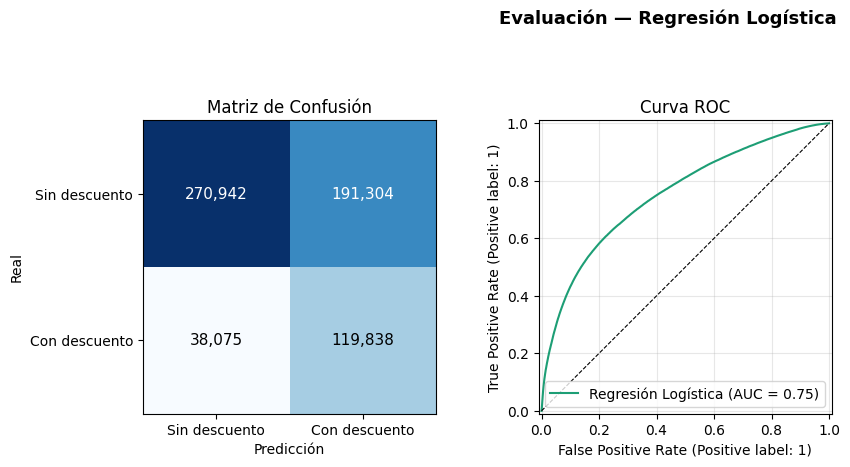

              precision    recall  f1-score   support

           0       0.88      0.59      0.70    462246
           1       0.39      0.76      0.51    157913

    accuracy                           0.63    620159
   macro avg       0.63      0.67      0.61    620159
weighted avg       0.75      0.63      0.65    620159



In [200]:
plot_modelo(
    'Regresión Logística',
    y_test,
    y_pred_lr,
    pipeline_lr.predict_proba(X_test)[:,1]
)
print(classification_report(y_test, y_pred_lr))


In [201]:
pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   RandomForestClassifier(
                    n_estimators=200,
                    class_weight='balanced',
                    random_state=31,
                    n_jobs=-1
                ))
])

In [202]:
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)

In [203]:
mejor_threeshold= 0.27

y_pred_final = (pipeline_rf.predict_proba(X_test)[:,1] >= mejor_threeshold).astype(int)

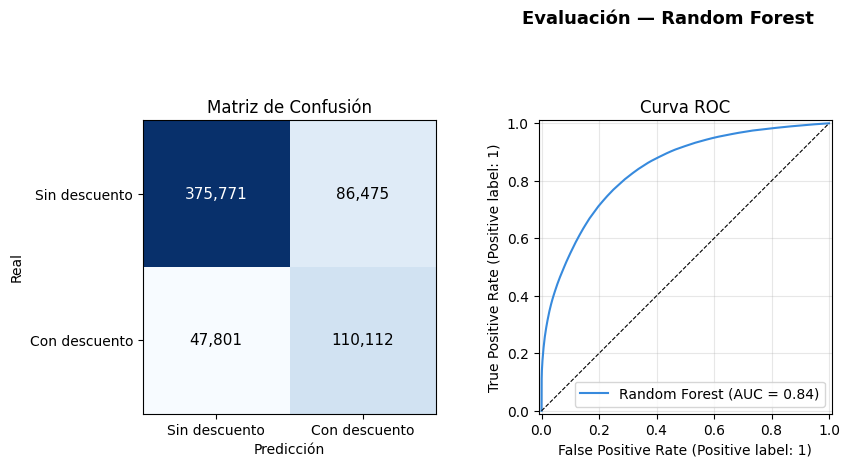

              precision    recall  f1-score   support

           0       0.89      0.81      0.85    462246
           1       0.56      0.70      0.62    157913

    accuracy                           0.78    620159
   macro avg       0.72      0.76      0.73    620159
weighted avg       0.80      0.78      0.79    620159



In [204]:
probs_rf = pipeline_rf.predict_proba(X_test)[:,1]
y_pred_rf_opt = (probs_rf >= 0.27).astype(int)
plot_modelo('Random Forest', y_test, y_pred_rf_opt, probs_rf, color='#378ADD')
print(classification_report(y_test, y_pred_rf_opt))


In [205]:

pipeline_hgb = Pipeline([
    ('model', HistGradientBoostingClassifier(
                class_weight='balanced',
                random_state=31,
                max_iter=200
              ))
])

pipeline_hgb.fit(X_train, y_train)
y_pred_hgb = pipeline_hgb.predict(X_test)


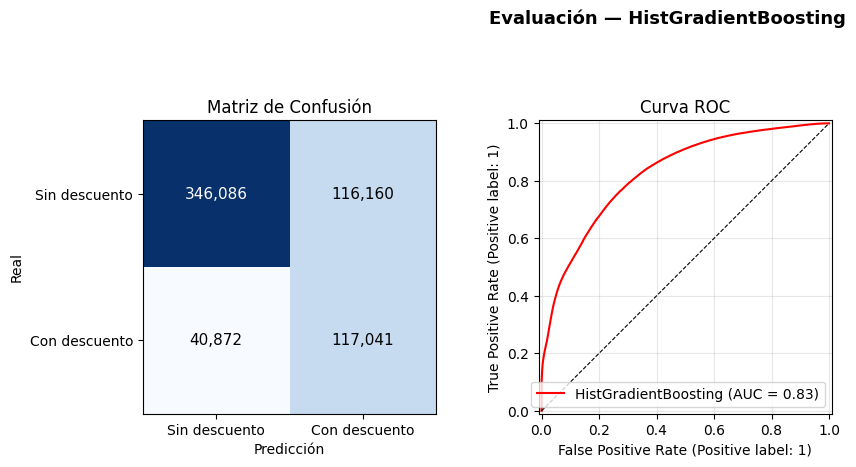

              precision    recall  f1-score   support

           0       0.89      0.75      0.82    462246
           1       0.50      0.74      0.60    157913

    accuracy                           0.75    620159
   macro avg       0.70      0.74      0.71    620159
weighted avg       0.79      0.75      0.76    620159



In [206]:
plot_modelo(
    'HistGradientBoosting',
    y_test,
    y_pred_hgb,
    pipeline_hgb.predict_proba(X_test)[:,1],
    color='red'
)
print(classification_report(y_test, y_pred_hgb))


In [207]:

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

pipeline_xgb = Pipeline([
    ('model', XGBClassifier(
                scale_pos_weight=scale_pos_weight,
                n_estimators=200,
                random_state=31,
                n_jobs=10,
                eval_metric='logloss'
              ))
])


In [208]:
pipeline_xgb.fit(X_train, y_train)
y_pred_xgb = pipeline_xgb.predict(X_test)

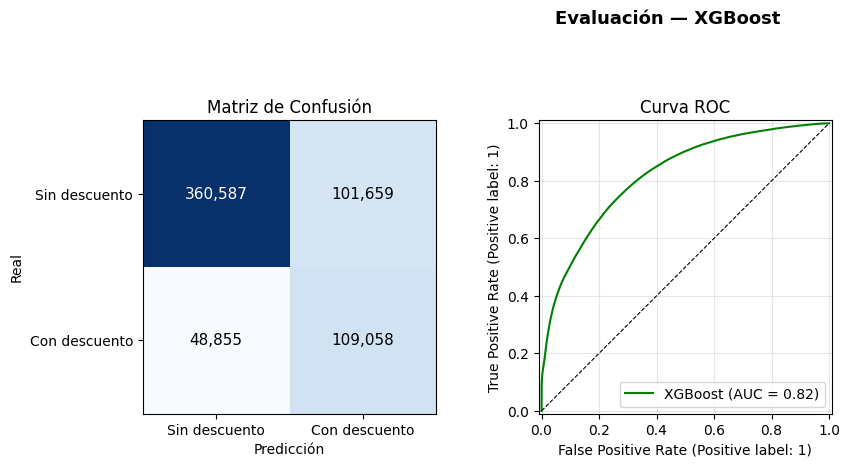

In [209]:
plot_modelo(
    'XGBoost',
    y_test,
    y_pred_xgb,
    pipeline_xgb.predict_proba(X_test)[:,1],
    color='green'
)

In [210]:
importancias = pd.DataFrame({
    'feature': FEATURES_COLS,
    'importancia': pipeline_rf.named_steps['model'].feature_importances_
}).sort_values('importancia', ascending=False)


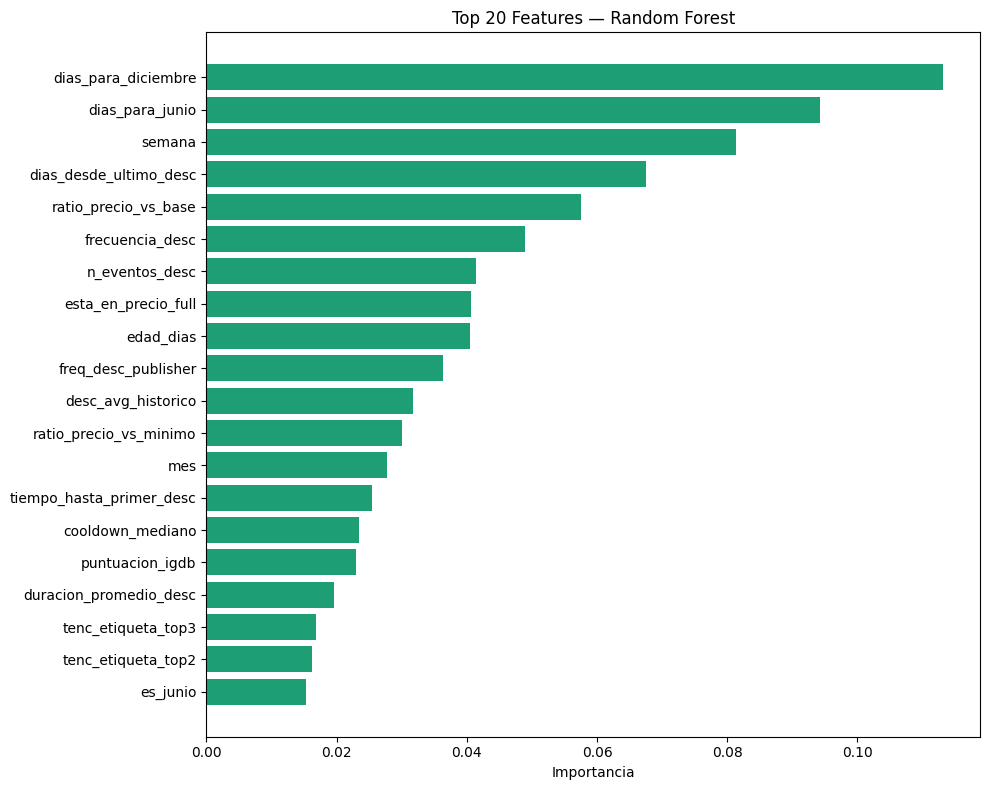

In [211]:
plt.figure(figsize=(10, 8))
plt.barh(importancias['feature'][:20][::-1], 
         importancias['importancia'][:20][::-1], 
         color='#1D9E75')
plt.xlabel('Importancia')
plt.title('Top 20 Features — Random Forest')
plt.tight_layout()
plt.savefig(IMAGENES_PATH +'Caracteristicas mass importantes'+ '.png', dpi=150, bbox_inches='tight')
plt.show()

In [212]:
MODEL_PATH = ROOT / 'models'

joblib.dump(pipeline_rf,     MODEL_PATH / 'modelo_descuentos_rf.pkl')
joblib.dump(mejor_threeshold, MODEL_PATH / 'threshold_descuentos.pkl')
joblib.dump(FEATURES_COLS,   MODEL_PATH / 'features_cols.pkl')
joblib.dump(importancias,    MODEL_PATH / 'feature_importances_rf.pkl')


['c:\\Proyectos\\GameLens\\models\\feature_importances_rf.pkl']

In [213]:
MODEL_PATH.resolve()

WindowsPath('C:/Proyectos/GameLens/models')